# 05_robustness_reader_and_radiology_demo_residualization

This notebook does two things:

1. Adds the missing **radiology demo-only residualization with leakage test** and saves the outputs.
2. Reads the saved outputs from **all robustness analyses** and prints the result tables.

Run this notebook from the same directory that contains:

- `02_radiology.ipynb`
- `03_icu_pressor_vent_ipsw.ipynb`

and the corresponding `main/` output folders.


In [2]:
from pathlib import Path
import json
import gzip
import pickle

import nbformat
import numpy as np
import pandas as pd
from IPython.display import display, Markdown


ROOT = Path(".")
MAIN = ROOT / "main"
RAD_MAIN = MAIN / "radiology"
ICU_MAIN = MAIN / "icu"
RAD_SHARED = MAIN / "shared" / "radiology"

PRESSOR_SHARED = MAIN / "shared" / "pressor"
VENT_SHARED = MAIN / "shared" / "vent"

RAD_NOTEBOOK = Path("02_radiology.ipynb")
ICU_NOTEBOOK = Path("03_icu_pressor_vent_ipsw.ipynb")


def exec_notebook_code_cells(notebook_path: Path, indices: list[int], env: dict | None = None):
    nb = nbformat.read(notebook_path, as_version=4)
    scope = dict(globals())
    if env is not None:
        scope.update(env)
    for idx in indices:
        cell = nb.cells[idx]
        if cell.cell_type != "code":
            continue
        code = compile(cell.source, f"{notebook_path.name}:cell_{idx}", "exec")
        exec(code, scope)
    return scope


def show_title(text: str):
    display(Markdown(f"## {text}"))


def show_subtitle(text: str):
    display(Markdown(f"### {text}"))


def read_parquet_if_exists(path: Path):
    if not path.exists():
        print(f"Missing: {path}")
        return None
    print(path)
    return pd.read_parquet(path)


def display_df(df: pd.DataFrame | None, sort_by: list[str] | None = None, head: int | None = None):
    if df is None:
        return
    out = df.copy()
    if sort_by is not None:
        keep = [c for c in sort_by if c in out.columns]
        if keep:
            out = out.sort_values(keep).reset_index(drop=True)
    if head is not None:
        print(out.head(head))
    else:
        print(out)


In [3]:
# Radiology helper functions and saved analysis assets from the original notebook.
# Only the needed helper cells are executed here.

SEED = 2026
TAU = 6.0
TEXT_COL = "chiefcomplaint"
OUTCOME_TIME_COLS = [
    "time_to_any_rad_hours",
    "time_to_advanced_hours",
    "time_to_xray_hours",
]
REF = {
    "gender": "F",
    "race": "White",
    "language": "English",
}
GROUP_VARS = ["gender", "race", "language"]
ASSET_DIR = RAD_SHARED

# Load the saved radiology analysis-ready assets.
radiology_analytic = pd.read_parquet(ASSET_DIR / "radiology_analytic_imputed.parquet").reset_index(drop=True)
radiology_text = pd.read_parquet(ASSET_DIR / "radiology_text_bundle.parquet").reset_index(drop=True)
selection_weights = pd.read_parquet(RAD_MAIN / "selection" / "selection_weights.parquet")

z_cols = [c for c in radiology_text.columns if c.startswith("z_")]
for c in z_cols:
    radiology_analytic[c] = radiology_text[c].to_numpy()

rad_env = {
    "SEED": SEED,
    "TAU": TAU,
    "TEXT_COL": TEXT_COL,
    "OUTCOME_TIME_COLS": OUTCOME_TIME_COLS,
    "REF": REF,
    "GROUP_VARS": GROUP_VARS,
    "ASSET_DIR": ASSET_DIR,
    "ROOT": ROOT,
    "MAIN": MAIN,
    "RAD_MAIN": RAD_MAIN,
    "radiology_analytic": radiology_analytic,
    "radiology_text": radiology_text,
    "selection_weights": selection_weights,
    "z_cols": z_cols,
}

rad_env = exec_notebook_code_cells(RAD_NOTEBOOK, [2, 11, 12], rad_env)
globals().update(rad_env)

base_adjust_cols = [
    "anchor_age",
    "anchor_age_sq",
    "acuity",
    "temperature",
    "heartrate",
    "resprate",
    "o2sat",
    "sbp",
    "dbp",
    "pain",
    "pain_critical",
    "temperature_c_like",
    "cc_missing",
    "arrival_transport",
    "insurance",
]
text_adjust_cols = list(dict.fromkeys(base_adjust_cols + z_cols))

analytic_main = radiology_analytic.merge(
    selection_weights.loc[
        selection_weights["selected_into_radiology"] == 1,
        ["stay_id", "selection_weight"],
    ].rename(columns={"stay_id": "ed_stay_id"}),
    on="ed_stay_id",
    how="left",
)
analytic_main["selection_weight"] = analytic_main["selection_weight"].where(
    analytic_main["selection_weight"].notna(),
    1.0,
)

OUTCOME_SPECS = [{"time_col": c, "tau": TAU} for c in OUTCOME_TIME_COLS]
MAIN_SCHEME_MAP = {
    "structured": {
        "structured_cols": GROUP_VARS + base_adjust_cols,
        "text_cols": None,
        "ipw_adjust_cols": base_adjust_cols,
        "trim_q": MAIN_TRIM_Q,
    },
    "structured_plus_text": {
        "structured_cols": GROUP_VARS + base_adjust_cols,
        "text_cols": z_cols,
        "ipw_adjust_cols": text_adjust_cols,
        "trim_q": MAIN_TRIM_Q,
    },
}


torch device: mps


In [4]:
# Radiology demo-only residualization with leakage test.
# This block mirrors the ICU robustness check and saves the outputs under main/radiology/robustness.

FORCE_RERUN_RADIOLOGY_DEMO_ONLY = False

resid_long_path = RAD_MAIN / "robustness" / "residualization_demo_only_long.parquet"
resid_compare_raw_path = RAD_MAIN / "robustness" / "residualization_demo_only_compare_raw.parquet"
resid_compare_resid_path = RAD_MAIN / "robustness" / "residualization_demo_only_compare_resid.parquet"
resid_shift_path = RAD_MAIN / "robustness" / "residualization_demo_only_shift.parquet"
resid_shift_summary_path = RAD_MAIN / "robustness" / "residualization_demo_only_shift_summary.parquet"
resid_r2_path = RAD_MAIN / "robustness" / "residualization_demo_only_r2.parquet"
resid_leakage_path = RAD_MAIN / "robustness" / "residualization_demo_only_leakage.parquet"

all_demo_resid_outputs_exist = all(
    p.exists()
    for p in [
        resid_long_path,
        resid_compare_raw_path,
        resid_compare_resid_path,
        resid_shift_path,
        resid_shift_summary_path,
        resid_r2_path,
        resid_leakage_path,
    ]
)

if all_demo_resid_outputs_exist and not FORCE_RERUN_RADIOLOGY_DEMO_ONLY:
    radiology_demo_only_shift_summary = pd.read_parquet(resid_shift_summary_path)
    radiology_demo_only_leakage = pd.read_parquet(resid_leakage_path)
    radiology_demo_only_r2 = pd.read_parquet(resid_r2_path)
else:
    resid_long_parts = []
    compare_raw_parts = []
    compare_resid_parts = []
    shift_parts = []
    r2_parts = []
    leakage_parts = []

    for outcome_spec in OUTCOME_SPECS:
        time_col = outcome_spec["time_col"]
        tau = outcome_spec["tau"]

        in_risk, duration, event = build_survival_target(analytic_main, time_col, tau)
        risk_df = analytic_main.loc[in_risk].reset_index(drop=True).copy()

        train_idx, val_idx = make_train_val_split(
            len(risk_df),
            seed=stable_seed("radiology_demo_resid_split", time_col),
            val_frac=VAL_FRAC,
        )

        z_res_df, resid_meta = make_demo_residualized_text_features(
            df=risk_df,
            text_cols=z_cols,
            demo_cols=GROUP_VARS,
            train_idx=train_idx,
            seed=stable_seed("radiology_demo_resid", time_col),
        )
        z_res_cols = z_res_df.columns.tolist()
        risk_aug = pd.concat([risk_df, z_res_df], axis=1)

        leakage_rows = []
        for target_col in GROUP_VARS:
            met_structured = evaluate_demographic_predictability(
                df=risk_aug,
                feature_cols=base_adjust_cols,
                target_col=target_col,
                train_idx=train_idx,
                val_idx=val_idx,
            )
            met_raw = evaluate_demographic_predictability(
                df=risk_aug,
                feature_cols=base_adjust_cols + z_cols,
                target_col=target_col,
                train_idx=train_idx,
                val_idx=val_idx,
            )
            met_resid = evaluate_demographic_predictability(
                df=risk_aug,
                feature_cols=base_adjust_cols + z_res_cols,
                target_col=target_col,
                train_idx=train_idx,
                val_idx=val_idx,
            )
            leakage_rows.append(
                {
                    "dataset": "radiology",
                    "outcome": time_col,
                    "target": target_col,
                    "log_loss_structured": met_structured["log_loss"],
                    "log_loss_structured_plus_raw_text": met_raw["log_loss"],
                    "log_loss_structured_plus_resid_text": met_resid["log_loss"],
                    "balanced_acc_structured": met_structured["balanced_acc"],
                    "balanced_acc_structured_plus_raw_text": met_raw["balanced_acc"],
                    "balanced_acc_structured_plus_resid_text": met_resid["balanced_acc"],
                }
            )

        scheme_map = {
            "structured": MAIN_SCHEME_MAP["structured"],
            "structured_plus_text": MAIN_SCHEME_MAP["structured_plus_text"],
            "structured_plus_text_resid": {
                "structured_cols": GROUP_VARS + base_adjust_cols,
                "text_cols": z_res_cols,
                "ipw_adjust_cols": list(dict.fromkeys(base_adjust_cols + z_res_cols)),
                "trim_q": MAIN_TRIM_Q,
            },
        }

        resid_long, _, _, _, _ = fit_weighted_subset_compare(
            analytic_sub=risk_aug,
            outcome_specs=[outcome_spec],
            scheme_map=scheme_map,
            left_scheme="structured",
            right_scheme="structured_plus_text",
            seed_prefix=f"radiology_demo_resid_{time_col}",
        )

        compare_raw = compare_disparity(
            tbl_left=resid_long.loc[resid_long["scheme"] == "structured"].copy(),
            tbl_right=resid_long.loc[resid_long["scheme"] == "structured_plus_text"].copy(),
            left_scheme="structured",
            right_scheme="structured_plus_text",
        )
        compare_resid = compare_disparity(
            tbl_left=resid_long.loc[resid_long["scheme"] == "structured"].copy(),
            tbl_right=resid_long.loc[resid_long["scheme"] == "structured_plus_text_resid"].copy(),
            left_scheme="structured",
            right_scheme="structured_plus_text_resid",
        )

        resid_long["dataset"] = "radiology"
        compare_raw["dataset"] = "radiology"
        compare_resid["dataset"] = "radiology"

        resid_long["outcome"] = time_col
        compare_raw["outcome"] = time_col
        compare_resid["outcome"] = time_col

        shift_df = summarize_shift_attenuation(compare_raw, compare_resid, "resid")
        shift_df["dataset"] = "radiology"
        shift_df["outcome"] = time_col

        resid_long_parts.append(resid_long)
        compare_raw_parts.append(compare_raw)
        compare_resid_parts.append(compare_resid)
        shift_parts.append(shift_df)
        r2_parts.append(pd.DataFrame([{"dataset": "radiology", "outcome": time_col, **resid_meta}]))
        leakage_parts.append(pd.DataFrame(leakage_rows))

    radiology_demo_only_long = pd.concat(resid_long_parts, ignore_index=True)
    radiology_demo_only_compare_raw = pd.concat(compare_raw_parts, ignore_index=True)
    radiology_demo_only_compare_resid = pd.concat(compare_resid_parts, ignore_index=True)
    radiology_demo_only_shift = pd.concat(shift_parts, ignore_index=True)
    radiology_demo_only_shift_summary = summarize_attenuation_table(radiology_demo_only_shift, "resid")
    radiology_demo_only_shift_summary["dataset"] = "radiology"
    radiology_demo_only_r2 = pd.concat(r2_parts, ignore_index=True)
    radiology_demo_only_leakage = pd.concat(leakage_parts, ignore_index=True)

    save_df_pair(radiology_demo_only_long, resid_long_path)
    save_df_pair(radiology_demo_only_compare_raw, resid_compare_raw_path)
    save_df_pair(radiology_demo_only_compare_resid, resid_compare_resid_path)
    save_df_pair(radiology_demo_only_shift, resid_shift_path)
    save_df_pair(radiology_demo_only_shift_summary, resid_shift_summary_path)
    save_df_pair(radiology_demo_only_r2, resid_r2_path)
    save_df_pair(radiology_demo_only_leakage, resid_leakage_path)

show_title("Radiology demo-only residualization")
display_df(radiology_demo_only_shift_summary, sort_by=["outcome", "group_var"])
show_subtitle("Radiology leakage")
display_df(radiology_demo_only_leakage, sort_by=["outcome", "target"])
show_subtitle("Radiology residualization R2")
display_df(radiology_demo_only_r2, sort_by=["outcome"])


## Radiology demo-only residualization

                  outcome group_var  n_levels  median_abs_delta_beta_raw  \
0  time_to_advanced_hours    gender         2                   0.006362   
1  time_to_advanced_hours  language         8                   0.172049   
2  time_to_advanced_hours      race         6                   0.089358   
3   time_to_any_rad_hours    gender         2                   0.031878   
4   time_to_any_rad_hours  language         8                   0.112559   
5   time_to_any_rad_hours      race         6                   0.081068   
6      time_to_xray_hours    gender         2                   0.001285   
7      time_to_xray_hours  language         8                   0.173578   
8      time_to_xray_hours      race         6                   0.130451   

   median_abs_delta_beta_alt  median_alt_share_beta  median_attenuation_beta  \
0                   0.034026               5.348291                -4.348291   
1                   0.113204               0.974758                 0.025242   

### Radiology leakage

     dataset                 outcome    target  log_loss_structured  \
0  radiology  time_to_advanced_hours    gender             0.674317   
1  radiology  time_to_advanced_hours  language             0.465461   
2  radiology  time_to_advanced_hours      race             1.028954   
3  radiology   time_to_any_rad_hours    gender             0.676189   
4  radiology   time_to_any_rad_hours  language             0.462799   
5  radiology   time_to_any_rad_hours      race             1.029075   
6  radiology      time_to_xray_hours    gender             0.675225   
7  radiology      time_to_xray_hours  language             0.469325   
8  radiology      time_to_xray_hours      race             1.031578   

   log_loss_structured_plus_raw_text  log_loss_structured_plus_resid_text  \
0                           0.668775                             0.673041   
1                           0.461621                             0.462873   
2                           1.018375                      

### Radiology residualization R2

     dataset                 outcome   r2_mean   r2_varw
0  radiology  time_to_advanced_hours  0.004049  0.004700
1  radiology   time_to_any_rad_hours  0.004051  0.004703
2  radiology      time_to_xray_hours  0.004052  0.004706


# Curated robustness and diagnostics display

This section excludes inference-only outputs. DAGJ and token stability are treated as main results, not sensitivity checks.

In [5]:
# Curated robustness display helpers.

import pickle
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 240)

PLOT_TITLE_FONTSIZE = 30
PLOT_LABEL_FONTSIZE = 23
PLOT_TICK_FONTSIZE = 20
PLOT_LEGEND_FONTSIZE = 18

DATASET_BASES = {
    "radiology": MAIN / "radiology",
    "pressor": MAIN / "icu" / "pressor",
    "vent": MAIN / "icu" / "vent",
}

BUNDLE_DIRS = {
    "radiology": MAIN / "radiology" / "bootstrap_state_bundle",
    "pressor": MAIN / "icu" / "pressor" / "dagjackknife_bundle",
    "vent": MAIN / "icu" / "vent" / "dagjackknife_bundle",
}

MAIN_COMPARE_PATHS = {
    "radiology": MAIN / "radiology" / "main" / "radiology_weighted_compare.parquet",
    "pressor": MAIN / "icu" / "pressor" / "main" / "pressor_weighted_compare.parquet",
    "vent": MAIN / "icu" / "vent" / "main" / "vent_weighted_compare.parquet",
}

ROBUSTNESS_DIRS = {
    name: base / "robustness"
    for name, base in DATASET_BASES.items()
}

KEY_COLS = ["dataset", "outcome", "family_var", "group_var", "level", "ref_level", "term"]


def dataset_bundle_dir(dataset: str) -> Path:
    return BUNDLE_DIRS[dataset]


def main_compare_path(dataset: str) -> Path:
    return MAIN_COMPARE_PATHS[dataset]


def print_section(title: str):
    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)


def print_table(df: pd.DataFrame, title: str, max_rows: int = 120):
    print_section(title)
    if df is None or len(df) == 0:
        print("No rows.")
        return
    out = df.copy()
    if len(out) > max_rows:
        print(out.head(max_rows).to_string(index=False))
        print(f"\nShowing {max_rows} of {len(out)} rows.")
    else:
        print(out.to_string(index=False))


def read_dataset_file(filename: str, subdir: str = "robustness"):
    rows = []
    for dataset, base in DATASET_BASES.items():
        path = (base / subdir / filename) if subdir else (base / filename)
        if path.exists():
            df = pd.read_parquet(path).copy()
            if "dataset" not in df.columns:
                df["dataset"] = dataset
            rows.append(df)
    if len(rows) == 0:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def read_dataset_path_map(path_builder):
    rows = []
    for dataset, base in DATASET_BASES.items():
        path = path_builder(dataset, base)
        if path.exists():
            df = pd.read_parquet(path).copy()
            if "dataset" not in df.columns:
                df["dataset"] = dataset
            rows.append(df)
    if len(rows) == 0:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


def load_main_compare_all():
    rows = []
    for dataset, base in DATASET_BASES.items():
        dagj_path = base / "delete_a_group_jackknife" / "jackknife_summary.parquet"
        bundle_compare_path = dataset_bundle_dir(dataset) / "compare_results.parquet"
        main_path = main_compare_path(dataset)

        if dagj_path.exists():
            df = pd.read_parquet(dagj_path).copy()
        elif bundle_compare_path.exists():
            df = pd.read_parquet(bundle_compare_path).copy()
        elif main_path.exists():
            df = pd.read_parquet(main_path).copy()
        else:
            raise FileNotFoundError(
                f"No main comparison file found for {dataset}. Checked: "
                f"{dagj_path}, {bundle_compare_path}, {main_path}"
            )

        if "dataset" not in df.columns:
            df["dataset"] = dataset

        keep_cols = [c for c in KEY_COLS + ["delta_beta", "HR_ratio", "delta_beta_jackknife_se", "HR_ratio_jackknife_se"] if c in df.columns]
        rows.append(df[keep_cols].copy())

    out = pd.concat(rows, ignore_index=True)
    rename = {}
    if "delta_beta" in out.columns:
        rename["delta_beta"] = "delta_beta_main"
    if "HR_ratio" in out.columns:
        rename["HR_ratio"] = "HR_ratio_main"
    return out.rename(columns=rename)


def finite_xy(df: pd.DataFrame, x_col: str, y_col: str):
    x = pd.to_numeric(df[x_col], errors="coerce")
    y = pd.to_numeric(df[y_col], errors="coerce")
    mask = np.isfinite(x.to_numpy(dtype=float)) & np.isfinite(y.to_numpy(dtype=float))
    return df.loc[mask].copy(), x.loc[mask].to_numpy(dtype=float), y.loc[mask].to_numpy(dtype=float)



def pretty_level_name(term, group_var):
    prefix = f"{group_var}_"
    if isinstance(term, str) and term.startswith(prefix):
        val = term[len(prefix):]
    else:
        val = term

    val = str(val).replace("_", " ").strip()
    if group_var == "gender":
        if val == "M":
            return "Male"
        if val == "F":
            return "Female"
    return val.title()


GROUP_ORDER = ["gender", "race", "language"]
GROUP_TITLE_MAP = {
    "gender": "Gender",
    "race": "Race",
    "language": "Language",
}
OUTCOME_ORDER = [
    "time_to_xray_hours",
    "time_to_any_rad_hours",
    "time_to_advanced_hours",
    "time_to_pressor_hours",
    "time_to_vent_hours",
]
OUTCOME_LABEL_MAP = {
    "time_to_xray_hours": "X-ray",
    "time_to_any_rad_hours": "Any radiology",
    "time_to_advanced_hours": "Advanced imaging",
    "time_to_pressor_hours": "Vasopressor",
    "time_to_vent_hours": "Ventilation",
}


def _ordered_outcomes(values):
    present = [str(x) for x in pd.Series(values).astype("string").unique().tolist()]
    ordered = [x for x in OUTCOME_ORDER if x in present]
    extras = sorted([x for x in present if x not in ordered])
    return ordered + extras


def _finite_any_row(df: pd.DataFrame, value_cols: list[str]):
    keep = np.zeros(len(df), dtype=bool)
    for col in value_cols:
        vals = pd.to_numeric(df[col], errors="coerce").to_numpy(dtype=float)
        keep |= np.isfinite(vals)
    return df.loc[keep].copy()


def plot_sensitivity_bar_comparison(
    df: pd.DataFrame,
    value_specs: list[tuple[str, str]],
    title: str,
    ylabel: str = "Delta beta",
    group_col: str = "group_var",
    outcome_col: str = "outcome",
    term_col: str = "term",
    level_col: str = "level",
    ref_col: str = "ref_level",
):
    if df is None or len(df) == 0:
        print(f"No rows to plot: {title}")
        return

    value_cols = [col for _, col in value_specs]
    missing_cols = [col for col in [group_col, outcome_col, term_col] + value_cols if col not in df.columns]
    if len(missing_cols) > 0:
        print(f"Missing columns for plot {title}: {missing_cols}")
        return

    plot_df = df.copy()
    if level_col in plot_df.columns and ref_col in plot_df.columns:
        plot_df = plot_df.loc[plot_df[level_col].astype(str) != plot_df[ref_col].astype(str)].copy()

    plot_df = _finite_any_row(plot_df, value_cols)
    if len(plot_df) == 0:
        print(f"No finite values to plot: {title}")
        return

    groups = [g for g in GROUP_ORDER if g in set(plot_df[group_col].astype(str))]
    groups += [g for g in sorted(set(plot_df[group_col].astype(str))) if g not in groups]
    outcomes = _ordered_outcomes(plot_df[outcome_col])

    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    outcome_to_color = {
        outcome: color_cycle[i % len(color_cycle)]
        for i, outcome in enumerate(outcomes)
    }

    if set(["gender", "race", "language"]).issubset(set(groups)):
        fig = plt.figure(figsize=(30, 16))
        gs = GridSpec(2, 3, figure=fig)
        axes = {
            "gender": fig.add_subplot(gs[0, 0]),
            "race": fig.add_subplot(gs[0, 1:3]),
            "language": fig.add_subplot(gs[1, 0:3]),
        }
        active_groups = ["gender", "race", "language"]
    else:
        fig, ax_arr = plt.subplots(len(groups), 1, figsize=(30, max(8, 6 * len(groups))))
        if len(groups) == 1:
            ax_arr = [ax_arr]
        axes = {g: ax for g, ax in zip(groups, ax_arr)}
        active_groups = groups

    fig.subplots_adjust(
        left=0.07,
        right=0.995,
        bottom=0.16,
        top=0.86,
        wspace=0.20,
        hspace=0.70,
    )

    all_vals = []
    for col in value_cols:
        vals = pd.to_numeric(plot_df[col], errors="coerce").to_numpy(dtype=float)
        all_vals.extend(vals[np.isfinite(vals)].tolist())
    ymax = max([abs(v) for v in all_vals], default=0.1) * 1.35
    if ymax == 0:
        ymax = 0.1

    spacing_cfg = {
        "gender": {"bar_w": 0.16, "outcome_gap": 0.52, "label_gap": 1.10},
        "race": {"bar_w": 0.22, "outcome_gap": 0.50, "label_gap": 0.62},
        "language": {"bar_w": 0.22, "outcome_gap": 0.50, "label_gap": 0.62},
    }
    default_spacing = {"bar_w": 0.20, "outcome_gap": 0.55, "label_gap": 0.80}

    n_measures = len(value_specs)
    alpha_values = np.linspace(0.35, 0.95, n_measures) if n_measures > 1 else np.array([0.95])

    for group_var in active_groups:
        ax = axes[group_var]
        sub = plot_df.loc[plot_df[group_col].astype(str).eq(group_var)].copy()
        if len(sub) == 0:
            ax.set_visible(False)
            continue

        cfg = spacing_cfg.get(group_var, default_spacing)
        bar_w = cfg["bar_w"]
        outcome_gap = cfg["outcome_gap"]
        label_gap = cfg["label_gap"]

        order_score = sub.copy()
        score = np.zeros(len(order_score), dtype=float)
        for col in value_cols:
            vals = pd.to_numeric(order_score[col], errors="coerce").to_numpy(dtype=float)
            score = np.maximum(score, np.where(np.isfinite(vals), np.abs(vals), 0.0))
        order_score["_abs_plot_score"] = score
        term_order = (
            order_score.groupby(term_col, observed=False)["_abs_plot_score"]
            .max()
            .sort_values(ascending=False)
            .index
            .tolist()
        )

        xticks = []
        xticklabels = []
        level_centers = []
        level_labels = []
        x_cursor = 0.0

        offsets = (np.arange(n_measures) - (n_measures - 1) / 2.0) * bar_w

        for term in term_order:
            term_df = sub.loc[sub[term_col].eq(term)]
            positions_this_term = []

            for i_outcome, outcome in enumerate(outcomes):
                row_df = term_df.loc[term_df[outcome_col].astype(str).eq(outcome)]
                if len(row_df) == 0:
                    continue

                row = row_df.iloc[0]
                x0 = x_cursor + i_outcome * outcome_gap
                color = outcome_to_color[outcome]

                for j, (measure_label, value_col) in enumerate(value_specs):
                    value = pd.to_numeric(pd.Series([row[value_col]]), errors="coerce").iloc[0]
                    if not np.isfinite(float(value)):
                        continue
                    ax.bar(
                        x0 + offsets[j],
                        float(value),
                        width=bar_w * 0.88,
                        color=color,
                        alpha=float(alpha_values[j]),
                        edgecolor="black",
                        linewidth=1.2,
                        zorder=2,
                    )

                xticks.append(x0)
                xticklabels.append(OUTCOME_LABEL_MAP.get(outcome, str(outcome)))
                positions_this_term.append(x0)

            if len(positions_this_term) > 0:
                level_centers.append(float(np.mean(positions_this_term)))
                level_labels.append(pretty_level_name(term, group_var))

            x_cursor += len(outcomes) * outcome_gap + label_gap

        title_group = GROUP_TITLE_MAP.get(group_var, str(group_var).title())
        ax.set_title(title_group, fontsize=PLOT_TITLE_FONTSIZE, fontweight="bold")
        ax.set_xticks(xticks)
        ax.set_xticklabels(
            xticklabels,
            rotation=45,
            ha="right",
            rotation_mode="anchor",
            fontsize=PLOT_TICK_FONTSIZE,
        )
        ax.tick_params(axis="x", length=0, pad=22)
        ax.tick_params(axis="y", labelsize=PLOT_TICK_FONTSIZE)
        ax.grid(axis="y", linestyle="--", linewidth=0.8, alpha=0.35)
        ax.set_axisbelow(True)
        ax.axhline(0.0, linestyle="--", linewidth=1.4, color="black", alpha=0.8)
        ax.set_ylim(-ymax, ymax)

        label_y = ymax * 0.96
        for xpos, lbl in zip(level_centers, level_labels):
            ax.text(
                xpos,
                label_y,
                lbl,
                ha="center",
                va="top",
                fontsize=PLOT_LABEL_FONTSIZE,
            )

    first_visible = next((axes[g] for g in active_groups if axes[g].get_visible()), None)
    if first_visible is not None:
        first_visible.set_ylabel(ylabel, fontsize=PLOT_LABEL_FONTSIZE, fontweight="bold")

    fig.text(
        0.5,
        0.985,
        title,
        ha="center",
        va="top",
        fontsize=PLOT_TITLE_FONTSIZE,
        fontweight="bold",
    )

    measure_handles = [
        Patch(facecolor="gray", edgecolor="black", alpha=float(alpha_values[j]), label=label)
        for j, (label, _) in enumerate(value_specs)
    ]
    fig.legend(
        handles=measure_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, 0.945),
        ncol=min(len(measure_handles), 4),
        frameon=False,
        fontsize=PLOT_LEGEND_FONTSIZE + 4,
    )

    plt.show()


def plot_sensitivity_bar_facets(
    df: pd.DataFrame,
    value_specs: list[tuple[str, str]],
    title_prefix: str,
    facet_col: str,
    ylabel: str = "Delta beta",
):
    if df is None or len(df) == 0:
        print(f"No rows to plot: {title_prefix}")
        return
    if facet_col not in df.columns:
        plot_sensitivity_bar_comparison(df, value_specs, title_prefix, ylabel=ylabel)
        return

    facet_values = sorted(df[facet_col].astype(str).unique().tolist())
    for facet_value in facet_values:
        sub = df.loc[df[facet_col].astype(str).eq(facet_value)].copy()
        plot_sensitivity_bar_comparison(
            sub,
            value_specs,
            title=f"{title_prefix}: {facet_value}",
            ylabel=ylabel,
        )


def plot_metric_by_group(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    title: str,
    xlabel: str,
    ylabel: str,
):
    if df is None or len(df) == 0:
        print(f"No rows to plot: {title}")
        return

    plot_df = df.copy().reset_index(drop=True)
    plot_df[y_col] = pd.to_numeric(plot_df[y_col], errors="coerce")
    plot_df = plot_df.loc[np.isfinite(plot_df[y_col].to_numpy(dtype=float))].copy()

    fig, ax = plt.subplots(figsize=(14, 8))
    x = np.arange(len(plot_df))
    ax.bar(x, plot_df[y_col].to_numpy(dtype=float), width=0.75, alpha=0.85, edgecolor="black")
    ax.axhline(0.0, linewidth=1)

    labels = plot_df[x_col].astype(str).tolist()
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=60, ha="right", fontsize=PLOT_TICK_FONTSIZE)
    ax.set_title(title, fontsize=PLOT_TITLE_FONTSIZE)
    ax.set_xlabel(xlabel, fontsize=PLOT_LABEL_FONTSIZE)
    ax.set_ylabel(ylabel, fontsize=PLOT_LABEL_FONTSIZE)
    ax.tick_params(axis="y", labelsize=PLOT_TICK_FONTSIZE)
    fig.tight_layout()
    plt.show()


def add_main_delta(df: pd.DataFrame):
    main = load_main_compare_all()
    merge_cols = [c for c in KEY_COLS if c in df.columns and c in main.columns]
    main_value_cols = [c for c in main.columns if c not in merge_cols and c not in df.columns]
    return df.merge(main[merge_cols + main_value_cols], on=merge_cols, how="left")


def _finite_numeric_array(x):
    values = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    return values[np.isfinite(values)]


def make_sensitivity_shift_frame(
    df: pd.DataFrame,
    baseline_col: str,
    sensitivity_col: str,
    se_col: str | None = "delta_beta_jackknife_se",
):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    required_cols = [baseline_col, sensitivity_col]
    missing = [col for col in required_cols if col not in df.columns]
    if len(missing) > 0:
        print(f"Missing columns for sensitivity statistics: {missing}")
        return pd.DataFrame()

    out = df.copy()
    baseline = pd.to_numeric(out[baseline_col], errors="coerce").to_numpy(dtype=float)
    sensitivity = pd.to_numeric(out[sensitivity_col], errors="coerce").to_numpy(dtype=float)

    finite = np.isfinite(baseline) & np.isfinite(sensitivity)
    out = out.loc[finite].copy()
    baseline = baseline[finite]
    sensitivity = sensitivity[finite]

    out["baseline_delta_beta"] = baseline
    out["sensitivity_delta_beta"] = sensitivity
    out["gap_delta_beta"] = sensitivity - baseline
    out["abs_gap_delta_beta"] = np.abs(out["gap_delta_beta"].to_numpy(dtype=float))

    abs_baseline = np.abs(baseline)
    abs_gap = out["abs_gap_delta_beta"].to_numpy(dtype=float)

    out["abs_gap_over_abs_baseline"] = np.full(len(out), np.nan, dtype=float)
    ratio_mask = np.isfinite(abs_gap) & np.isfinite(abs_baseline) & (abs_baseline > 0)
    out.loc[ratio_mask, "abs_gap_over_abs_baseline"] = abs_gap[ratio_mask] / abs_baseline[ratio_mask]

    out["attenuation_ratio"] = np.full(len(out), np.nan, dtype=float)
    attenuation_mask = np.isfinite(sensitivity) & np.isfinite(baseline) & (baseline != 0)
    out.loc[attenuation_mask, "attenuation_ratio"] = sensitivity[attenuation_mask] / baseline[attenuation_mask]

    out["sign_flip"] = (
        (baseline != 0)
        & (sensitivity != 0)
        & (np.sign(baseline) != np.sign(sensitivity))
    )

    out["near_zero_baseline"] = np.nan
    out["meaningful_sign_flip"] = np.nan

    if se_col is not None and se_col in out.columns:
        se = pd.to_numeric(out[se_col], errors="coerce").to_numpy(dtype=float)
        abs_gap = out["abs_gap_delta_beta"].to_numpy(dtype=float)
        out["abs_gap_over_main_se"] = np.full(len(out), np.nan, dtype=float)
        se_mask = np.isfinite(abs_gap) & np.isfinite(se) & (se > 0)
        out.loc[se_mask, "abs_gap_over_main_se"] = abs_gap[se_mask] / se[se_mask]

        baseline_abs = np.abs(baseline)
        out.loc[se_mask, "near_zero_baseline"] = (baseline_abs[se_mask] < 0.5 * se[se_mask]).astype(float)
        out.loc[se_mask, "meaningful_sign_flip"] = (
            out.loc[se_mask, "sign_flip"].to_numpy(dtype=bool)
            & (baseline_abs[se_mask] >= 0.5 * se[se_mask])
            & (abs_gap[se_mask] >= 1.0 * se[se_mask])
        ).astype(float)
    else:
        out["abs_gap_over_main_se"] = np.nan

    return out


def summarize_sensitivity_shift_details(details: pd.DataFrame, group_cols: list[str] | None = None):
    if details is None or len(details) == 0:
        return pd.DataFrame()

    def summarize_one(x: pd.DataFrame):
        abs_gap = pd.to_numeric(x["abs_gap_delta_beta"], errors="coerce").to_numpy(dtype=float)
        sign_flip = x["sign_flip"].astype(bool).to_numpy()
        near_zero_baseline = pd.to_numeric(x["near_zero_baseline"], errors="coerce").to_numpy(dtype=float)
        meaningful_sign_flip = pd.to_numeric(x["meaningful_sign_flip"], errors="coerce").to_numpy(dtype=float)
        abs_gap_over_abs_baseline = pd.to_numeric(x["abs_gap_over_abs_baseline"], errors="coerce").to_numpy(dtype=float)
        attenuation_ratio = pd.to_numeric(x["attenuation_ratio"], errors="coerce").to_numpy(dtype=float)
        abs_gap_over_main_se = pd.to_numeric(x["abs_gap_over_main_se"], errors="coerce").to_numpy(dtype=float)

        finite_gap = abs_gap[np.isfinite(abs_gap)]
        finite_near_zero_baseline = near_zero_baseline[np.isfinite(near_zero_baseline)]
        finite_meaningful_sign_flip = meaningful_sign_flip[np.isfinite(meaningful_sign_flip)]
        finite_gap_over_abs_baseline = abs_gap_over_abs_baseline[np.isfinite(abs_gap_over_abs_baseline)]
        finite_attenuation = attenuation_ratio[np.isfinite(attenuation_ratio)]
        finite_gap_over_main_se = abs_gap_over_main_se[np.isfinite(abs_gap_over_main_se)]

        row = {
            "n_contrasts": int(len(x)),
            "median_abs_gap": float(np.median(finite_gap)) if len(finite_gap) else np.nan,
            "mean_abs_gap": float(np.mean(finite_gap)) if len(finite_gap) else np.nan,
            "p90_abs_gap": float(np.quantile(finite_gap, 0.90)) if len(finite_gap) else np.nan,
            "max_abs_gap": float(np.max(finite_gap)) if len(finite_gap) else np.nan,
            "sign_flip_rate": float(np.mean(sign_flip)) if len(sign_flip) else np.nan,
            "near_zero_baseline_rate": float(np.mean(finite_near_zero_baseline)) if len(finite_near_zero_baseline) else np.nan,
            "meaningful_sign_flip_rate": float(np.mean(finite_meaningful_sign_flip)) if len(finite_meaningful_sign_flip) else np.nan,
            "median_abs_gap_over_abs_baseline": float(np.median(finite_gap_over_abs_baseline)) if len(finite_gap_over_abs_baseline) else np.nan,
            "median_attenuation_ratio": float(np.median(finite_attenuation)) if len(finite_attenuation) else np.nan,
        }

        if len(finite_gap_over_main_se):
            row["median_abs_gap_over_main_se"] = float(np.median(finite_gap_over_main_se))
            row["share_gap_gt_0_5se"] = float(np.mean(finite_gap_over_main_se > 0.5))
            row["share_gap_gt_1se"] = float(np.mean(finite_gap_over_main_se > 1.0))
            row["share_gap_gt_2se"] = float(np.mean(finite_gap_over_main_se > 2.0))
        else:
            row["median_abs_gap_over_main_se"] = np.nan
            row["share_gap_gt_0_5se"] = np.nan
            row["share_gap_gt_1se"] = np.nan
            row["share_gap_gt_2se"] = np.nan

        return row

    if group_cols is None or len(group_cols) == 0:
        return pd.DataFrame([summarize_one(details)])

    rows = []
    for keys, sub in details.groupby(group_cols, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = {col: key for col, key in zip(group_cols, keys)}
        row.update(summarize_one(sub))
        rows.append(row)
    return pd.DataFrame(rows)



SENSITIVITY_OVERALL_SUMMARIES = []




def print_sensitivity_shift_statistics(
    df: pd.DataFrame,
    baseline_col: str,
    sensitivity_col: str,
    title: str,
    se_col: str | None = "delta_beta_jackknife_se",
    strata_cols: list[str] | None = None,
    top_n: int = 25,
):
    details = make_sensitivity_shift_frame(
        df=df,
        baseline_col=baseline_col,
        sensitivity_col=sensitivity_col,
        se_col=se_col,
    )

    print_section(title)
    if len(details) == 0:
        print("No finite sensitivity comparisons.")
        return details

    strata_cols = [col for col in (strata_cols or []) if col in details.columns]
    overall = summarize_sensitivity_shift_details(details, group_cols=None)
    overall.insert(0, "robustness", title)
    overall["n_variants"] = int(details[strata_cols].drop_duplicates().shape[0]) if len(strata_cols) else 1
    overall["baseline_col"] = baseline_col
    overall["sensitivity_col"] = sensitivity_col

    display_cols = [
        "robustness",
        "n_contrasts",
        "n_variants",
        "median_abs_gap",
        "p90_abs_gap",
        "max_abs_gap",
        "sign_flip_rate",
        "near_zero_baseline_rate",
        "meaningful_sign_flip_rate",
        "median_abs_gap_over_abs_baseline",
        "median_attenuation_ratio",
        "median_abs_gap_over_main_se",
        "share_gap_gt_0_5se",
        "share_gap_gt_1se",
        "share_gap_gt_2se",
    ]
    display_cols = [col for col in display_cols if col in overall.columns]
    print_table(overall.loc[:, display_cols], f"{title}: single overall shift summary", max_rows=20)

    SENSITIVITY_OVERALL_SUMMARIES.append(overall.copy())
    return details


def print_all_sensitivity_overall_summaries():
    print_section("Overall sensitivity summary across robustness checks")
    if len(SENSITIVITY_OVERALL_SUMMARIES) == 0:
        print("No overall sensitivity summaries have been generated yet.")
        return pd.DataFrame()

    out = pd.concat(SENSITIVITY_OVERALL_SUMMARIES, ignore_index=True)
    display_cols = [
        "robustness",
        "n_contrasts",
        "n_variants",
        "median_abs_gap",
        "p90_abs_gap",
        "max_abs_gap",
        "sign_flip_rate",
        "near_zero_baseline_rate",
        "meaningful_sign_flip_rate",
        "median_abs_gap_over_abs_baseline",
        "median_attenuation_ratio",
        "median_abs_gap_over_main_se",
        "share_gap_gt_0_5se",
        "share_gap_gt_1se",
        "share_gap_gt_2se",
    ]
    display_cols = [col for col in display_cols if col in out.columns]
    print_table(out.loc[:, display_cols], "All robustness checks: single-row overall summaries", max_rows=200)
    return out


HETEROGENEITY_OVERALL_SUMMARIES = []


def make_pairwise_heterogeneity_frame(
    df: pd.DataFrame,
    left_col: str,
    right_col: str,
    se_col: str | None = "delta_beta_jackknife_se",
):
    if df is None or len(df) == 0:
        return pd.DataFrame()

    missing = [col for col in [left_col, right_col] if col not in df.columns]
    if len(missing) > 0:
        print(f"Missing columns for pairwise heterogeneity statistics: {missing}")
        return pd.DataFrame()

    out = df.copy()
    left = pd.to_numeric(out[left_col], errors="coerce").to_numpy(dtype=float)
    right = pd.to_numeric(out[right_col], errors="coerce").to_numpy(dtype=float)
    finite = np.isfinite(left) & np.isfinite(right)
    out = out.loc[finite].copy()
    left = left[finite]
    right = right[finite]

    out["left_delta_beta"] = left
    out["right_delta_beta"] = right
    out["subgroup_gap_delta_beta"] = right - left
    out["abs_subgroup_gap_delta_beta"] = np.abs(out["subgroup_gap_delta_beta"].to_numpy(dtype=float))

    if se_col is not None and se_col in out.columns:
        se = pd.to_numeric(out[se_col], errors="coerce").to_numpy(dtype=float)
        abs_gap = out["abs_subgroup_gap_delta_beta"].to_numpy(dtype=float)
        out["abs_subgroup_gap_over_main_se"] = np.full(len(out), np.nan, dtype=float)
        se_mask = np.isfinite(abs_gap) & np.isfinite(se) & (se > 0)
        out.loc[se_mask, "abs_subgroup_gap_over_main_se"] = abs_gap[se_mask] / se[se_mask]
    else:
        out["abs_subgroup_gap_over_main_se"] = np.nan

    return out


def summarize_pairwise_heterogeneity_details(details: pd.DataFrame):
    if details is None or len(details) == 0:
        return pd.DataFrame()

    abs_gap = pd.to_numeric(details["abs_subgroup_gap_delta_beta"], errors="coerce").to_numpy(dtype=float)
    abs_gap_over_main_se = pd.to_numeric(details["abs_subgroup_gap_over_main_se"], errors="coerce").to_numpy(dtype=float)

    finite_gap = abs_gap[np.isfinite(abs_gap)]
    finite_gap_over_main_se = abs_gap_over_main_se[np.isfinite(abs_gap_over_main_se)]

    row = {
        "n_contrasts": int(len(details)),
        "median_abs_subgroup_gap": float(np.median(finite_gap)) if len(finite_gap) else np.nan,
        "mean_abs_subgroup_gap": float(np.mean(finite_gap)) if len(finite_gap) else np.nan,
        "p90_abs_subgroup_gap": float(np.quantile(finite_gap, 0.90)) if len(finite_gap) else np.nan,
        "max_abs_subgroup_gap": float(np.max(finite_gap)) if len(finite_gap) else np.nan,
    }

    if len(finite_gap_over_main_se):
        row["median_abs_subgroup_gap_over_main_se"] = float(np.median(finite_gap_over_main_se))
        row["share_subgroup_gap_gt_0_5se"] = float(np.mean(finite_gap_over_main_se > 0.5))
        row["share_subgroup_gap_gt_1se"] = float(np.mean(finite_gap_over_main_se > 1.0))
        row["share_subgroup_gap_gt_2se"] = float(np.mean(finite_gap_over_main_se > 2.0))
    else:
        row["median_abs_subgroup_gap_over_main_se"] = np.nan
        row["share_subgroup_gap_gt_0_5se"] = np.nan
        row["share_subgroup_gap_gt_1se"] = np.nan
        row["share_subgroup_gap_gt_2se"] = np.nan

    return pd.DataFrame([row])



def print_pairwise_heterogeneity_statistics(
    df: pd.DataFrame,
    left_col: str,
    right_col: str,
    title: str,
    se_col: str | None = "delta_beta_jackknife_se",
):
    details = make_pairwise_heterogeneity_frame(
        df=df,
        left_col=left_col,
        right_col=right_col,
        se_col=se_col,
    )

    print_section(title)
    if len(details) == 0:
        print("No finite subgroup comparisons.")
        return details

    overall = summarize_pairwise_heterogeneity_details(details)
    overall.insert(0, "analysis", title)
    overall["left_col"] = left_col
    overall["right_col"] = right_col

    display_cols = [
        "analysis",
        "n_contrasts",
        "median_abs_subgroup_gap",
        "p90_abs_subgroup_gap",
        "max_abs_subgroup_gap",
        "median_abs_subgroup_gap_over_main_se",
        "share_subgroup_gap_gt_0_5se",
        "share_subgroup_gap_gt_1se",
        "share_subgroup_gap_gt_2se",
    ]
    print_table(overall.loc[:, display_cols], f"{title}: single overall subgroup-gap summary", max_rows=20)

    HETEROGENEITY_OVERALL_SUMMARIES.append(overall.copy())
    return details


def print_all_heterogeneity_overall_summaries():
    print_section("Overall subgroup heterogeneity summary")
    if len(HETEROGENEITY_OVERALL_SUMMARIES) == 0:
        print("No overall subgroup heterogeneity summaries have been generated yet.")
        return pd.DataFrame()

    out = pd.concat(HETEROGENEITY_OVERALL_SUMMARIES, ignore_index=True)
    display_cols = [
        "analysis",
        "n_contrasts",
        "median_abs_subgroup_gap",
        "p90_abs_subgroup_gap",
        "max_abs_subgroup_gap",
        "median_abs_subgroup_gap_over_main_se",
        "share_subgroup_gap_gt_0_5se",
        "share_subgroup_gap_gt_1se",
        "share_subgroup_gap_gt_2se",
        
    ]
    print_table(out.loc[:, display_cols], "All subgroup heterogeneity checks: single-row overall summaries", max_rows=200)
    return out



def save_df_pair(df: pd.DataFrame, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    df.to_parquet(path, index=False)
    df.to_csv(path.with_suffix(".csv"), index=False)

## Path audit


In [6]:
# Path audit for all files used in the curated robustness display.

REQUIRED_PATHS = []
OPTIONAL_PATHS = []

for dataset, base in DATASET_BASES.items():
    REQUIRED_PATHS.extend([
        {"dataset": dataset, "path_type": "dataset_base", "path": base},
        {"dataset": dataset, "path_type": "bundle_dir", "path": dataset_bundle_dir(dataset)},
        {"dataset": dataset, "path_type": "main_artifacts", "path": dataset_bundle_dir(dataset) / "main_artifacts.pkl"},
        {"dataset": dataset, "path_type": "reference_map", "path": dataset_bundle_dir(dataset) / "REF.pkl"},
        {"dataset": dataset, "path_type": "main_compare", "path": main_compare_path(dataset)},
        {"dataset": dataset, "path_type": "shared_analytic", "path": MAIN / "shared" / dataset / f"{dataset}_analytic_imputed.parquet"},
    ])

    OPTIONAL_PATHS.extend([
        {"dataset": dataset, "path_type": "dagj_summary", "path": base / "delete_a_group_jackknife" / "jackknife_summary.parquet"},
        {"dataset": dataset, "path_type": "dagj_diagnostics", "path": base / "delete_a_group_jackknife" / "jackknife_diagnostics.parquet"},
        {"dataset": dataset, "path_type": "demo_residualization_shift", "path": base / "robustness" / "residualization_demo_only_shift.parquet"},
        {"dataset": dataset, "path_type": "demo_residualization_summary", "path": base / "robustness" / "residualization_demo_only_shift_summary.parquet"},
        {"dataset": dataset, "path_type": "demo_residualization_r2", "path": base / "robustness" / "residualization_demo_only_r2.parquet"},
        {"dataset": dataset, "path_type": "leakage", "path": base / "robustness" / "residualization_demo_only_leakage.parquet"},
        {"dataset": dataset, "path_type": "conditional_residualization_shift", "path": base / "robustness" / "conditional_residualization_shift.parquet"},
        {"dataset": dataset, "path_type": "conditional_residualization_summary", "path": base / "robustness" / "conditional_residualization_shift_summary.parquet"},
        {"dataset": dataset, "path_type": "conditional_residualization_r2", "path": base / "robustness" / "conditional_residualization_r2.parquet"},
        {"dataset": dataset, "path_type": "objective_complaint_vs_full", "path": base / "robustness" / "objective_complaint_vs_full.parquet"},
        {"dataset": dataset, "path_type": "objective_complaint_summary", "path": base / "robustness" / "objective_complaint_summary.parquet"},
        {"dataset": dataset, "path_type": "transfer_shift", "path": base / "robustness" / "transfer_shift.parquet"},
        {"dataset": dataset, "path_type": "transfer_summary", "path": base / "robustness" / "transfer_shift_summary.parquet"},
        {"dataset": dataset, "path_type": "transfer_counts", "path": base / "robustness" / "transfer_subgroups_counts.parquet"},
        {"dataset": dataset, "path_type": "complaint_heterogeneity_summary", "path": base / "robustness" / "complaint_heterogeneity_summary.parquet"},
        {"dataset": dataset, "path_type": "complaint_heterogeneity_top_diff", "path": base / "robustness" / "complaint_heterogeneity_top_diff.parquet"},
        {"dataset": dataset, "path_type": "fixed_weighting_compare", "path": base / "robustness" / "fixed_weighting_compare.parquet"},
        {"dataset": dataset, "path_type": "fixed_weighting_summary", "path": base / "robustness" / "fixed_weighting_summary.parquet"},
        {"dataset": dataset, "path_type": "fixed_weighting_diagnostics", "path": base / "robustness" / "fixed_weighting_diagnostics.parquet"},
    ])

path_audit_required = pd.DataFrame(REQUIRED_PATHS)
path_audit_optional = pd.DataFrame(OPTIONAL_PATHS)

for audit_df in [path_audit_required, path_audit_optional]:
    audit_df["path"] = audit_df["path"].map(Path)
    audit_df["exists"] = audit_df["path"].map(lambda p: p.exists())
    audit_df["path"] = audit_df["path"].astype(str)

print_table(
    path_audit_required.sort_values(["dataset", "path_type"]).reset_index(drop=True),
    "Required path audit",
    max_rows=300,
)

missing_required = path_audit_required.loc[~path_audit_required["exists"]].copy()
if len(missing_required) > 0:
    print_table(
        missing_required.sort_values(["dataset", "path_type"]).reset_index(drop=True),
        "Missing required paths",
        max_rows=300,
    )
    raise FileNotFoundError("Missing required paths listed above.")

print_table(
    path_audit_optional.sort_values(["dataset", "path_type"]).reset_index(drop=True),
    "Optional robustness path audit",
    max_rows=300,
)


Required path audit
  dataset       path_type                                                     path  exists
  pressor      bundle_dir                     main/icu/pressor/dagjackknife_bundle    True
  pressor    dataset_base                                         main/icu/pressor    True
  pressor  main_artifacts  main/icu/pressor/dagjackknife_bundle/main_artifacts.pkl    True
  pressor    main_compare   main/icu/pressor/main/pressor_weighted_compare.parquet    True
  pressor   reference_map             main/icu/pressor/dagjackknife_bundle/REF.pkl    True
  pressor shared_analytic     main/shared/pressor/pressor_analytic_imputed.parquet    True
radiology      bundle_dir                    main/radiology/bootstrap_state_bundle    True
radiology    dataset_base                                           main/radiology    True
radiology  main_artifacts main/radiology/bootstrap_state_bundle/main_artifacts.pkl    True
radiology    main_compare   main/radiology/main/radiology_weighted_co

## Diagnosis

In [7]:
# Read primary diagnostics, DAGJ stability, and fixed-weighting sensitivity.

MAIN_DIAG_PATHS = {
    "radiology": MAIN / "radiology" / "main" / "radiology_weighted_diagnostics.parquet",
    "pressor": MAIN / "icu" / "pressor" / "main" / "pressor_weighted_diagnostics.parquet",
    "vent": MAIN / "icu" / "vent" / "main" / "vent_weighted_diagnostics.parquet",
}

DAGJ_DIRS = {
    "radiology": MAIN / "radiology" / "delete_a_group_jackknife",
    "pressor": MAIN / "icu" / "pressor" / "delete_a_group_jackknife",
    "vent": MAIN / "icu" / "vent" / "delete_a_group_jackknife",
}


def read_main_diagnostics():
    out = []
    for dataset, path in MAIN_DIAG_PATHS.items():
        df = pd.read_parquet(path).copy()
        df["dataset"] = dataset
        out.append(df)
    return pd.concat(out, ignore_index=True)


def read_dagj_file(filename):
    out = []
    for dataset, path in DAGJ_DIRS.items():
        df = pd.read_parquet(path / filename).copy()
        df["dataset"] = dataset
        out.append(df)
    return pd.concat(out, ignore_index=True)


def q10(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.quantile(x, 0.10)) if x.size else np.nan


def q90(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.quantile(x, 0.90)) if x.size else np.nan


def finite_median_abs(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(np.abs(x))) if x.size else np.nan


def _cols(df, cols):
    return [c for c in cols if c in df.columns]


main_diag = read_main_diagnostics()

model_fit = main_diag.loc[
    main_diag["diagnostic_type"].astype(str).eq("model_fit")
].copy()

family_fit = main_diag.loc[
    main_diag["diagnostic_type"].astype(str).eq("family_weight_fit")
].copy()

if len(family_fit) > 0 and "n_family_levels" not in family_fit.columns and "n_levels" in family_fit.columns:
    family_fit["n_family_levels"] = family_fit["n_levels"]

model_fit["ess_over_n"] = model_fit["effective_sample_size"] / model_fit["n_rows"]
model_fit["weight_p99_over_p50"] = model_fit["weight_p99"] / model_fit["weight_p50"]
model_fit["weight_max_over_p50"] = model_fit["weight_max"] / model_fit["weight_p50"]

model_fit_sort_cols = _cols(model_fit, ["dataset", "outcome", "family_var", "scheme"])
print_table(
    model_fit.sort_values(model_fit_sort_cols)
    .loc[:, _cols(model_fit, [
        "dataset",
        "outcome",
        "family_var",
        "scheme",
        "trim_label",
        "n_rows",
        "n_event",
        "weight_min",
        "weight_p01",
        "weight_p50",
        "weight_p99",
        "weight_max",
        "weight_p99_over_p50",
        "weight_max_over_p50",
        "effective_sample_size",
        "ess_over_n",
        "cindex_train_weighted",
        "cindex_val_weighted",
    ])]
    .reset_index(drop=True),
    "1. Final analysis weight distribution / ESS",
    max_rows=300,
)

overlap_weight_summary = (
    model_fit
    .groupby(_cols(model_fit, ["dataset", "outcome", "family_var"]), as_index=False)
    .agg(
        min_ess_over_n=("ess_over_n", "min"),
        median_ess_over_n=("ess_over_n", "median"),
        max_weight_p99_over_p50=("weight_p99_over_p50", "max"),
        max_weight_max_over_p50=("weight_max_over_p50", "max"),
        min_cindex_val_weighted=("cindex_val_weighted", "min"),
        max_cindex_val_weighted=("cindex_val_weighted", "max"),
    )
)

print_table(
    overlap_weight_summary.sort_values(["min_ess_over_n", "max_weight_p99_over_p50"]).reset_index(drop=True),
    "1a. Outcome-family-level weight summary",
    max_rows=200,
)

if len(family_fit) > 0:
    family_fit["family_weight_p99_over_p50"] = family_fit["family_weight_p99"] / family_fit["family_weight_p50"]
    family_fit["family_weight_max_over_p50"] = family_fit["family_weight_max"] / family_fit["family_weight_p50"]
    family_fit["family_prob_p01_over_p50"] = family_fit["family_prob_p01"] / family_fit["family_prob_p50"]
    family_fit["family_prob_min_over_p50"] = family_fit["family_prob_min"] / family_fit["family_prob_p50"]

    print_table(
        family_fit.sort_values(_cols(family_fit, ["family_prob_p01", "family_weight_p99_over_p50"]))
        .loc[:, _cols(family_fit, [
            "dataset",
            "outcome",
            "family_var",
            "scheme",
            "n_rows",
            "n_family_levels",
            "family_class_observed",
            "family_prob_min",
            "family_prob_p01",
            "family_prob_p50",
            "family_prob_p99",
            "family_prob_max",
            "family_prob_p01_over_p50",
            "family_prob_min_over_p50",
            "family_weight_min",
            "family_weight_p01",
            "family_weight_p50",
            "family_weight_p99",
            "family_weight_max",
            "family_weight_p99_over_p50",
            "family_weight_max_over_p50",
        ])]
        .reset_index(drop=True),
        "2. Family-specific propensity support",
        max_rows=300,
    )

    positivity_summary = (
        family_fit
        .groupby(_cols(family_fit, ["dataset", "outcome", "family_var"]), as_index=False)
        .agg(
            min_family_prob_min=("family_prob_min", "min"),
            min_family_prob_p01=("family_prob_p01", "min"),
            median_family_prob_p50=("family_prob_p50", "median"),
            max_family_weight_p99_over_p50=("family_weight_p99_over_p50", "max"),
            max_family_weight_max_over_p50=("family_weight_max_over_p50", "max"),
            max_n_family_levels=("n_family_levels", "max"),
        )
    )

    print_table(
        positivity_summary.sort_values(["min_family_prob_p01", "max_family_weight_p99_over_p50"]).reset_index(drop=True),
        "2a. Outcome-family-level propensity summary",
        max_rows=200,
    )
else:
    print_table(family_fit, "2. Family-specific propensity support", max_rows=20)


dagj_summary = read_dagj_file("jackknife_summary.parquet")
dagj_compare = read_dagj_file("jackknife_compare.parquet")
dagj_diagnostics = read_dagj_file("jackknife_diagnostics.parquet")

dagj_model_diag = dagj_diagnostics.loc[
    dagj_diagnostics["diagnostic_type"].astype(str).eq("delete_group_model_fit")
].copy()

dagj_model_diag["ess_over_positive_weight"] = (
    dagj_model_diag["effective_sample_size"] / dagj_model_diag["n_rows_positive_weight"]
)
dagj_model_diag["weight_p99_over_p50"] = dagj_model_diag["weight_p99"] / dagj_model_diag["weight_p50"]
dagj_model_diag["weight_max_over_p50"] = dagj_model_diag["weight_max"] / dagj_model_diag["weight_p50"]

dagj_design_summary = (
    dagj_model_diag
    .groupby(_cols(dagj_model_diag, ["dataset", "outcome", "family_var", "scheme"]), as_index=False)
    .agg(
        n_delete_groups=("delete_group", "nunique"),
        min_n_rows_positive_weight=("n_rows_positive_weight", "min"),
        min_train_event_positive_weight=("n_train_event_positive_weight", "min"),
        min_val_event_positive_weight=("n_val_event_positive_weight", "min"),
        min_effective_sample_size=("effective_sample_size", "min"),
        median_effective_sample_size=("effective_sample_size", "median"),
        min_ess_over_positive_weight=("ess_over_positive_weight", "min"),
        median_ess_over_positive_weight=("ess_over_positive_weight", "median"),
        max_weight_p99_over_p50=("weight_p99_over_p50", "max"),
        max_weight_max_over_p50=("weight_max_over_p50", "max"),
        max_final_val_loss=("final_val_loss", "max"),
    )
)

print_table(
    dagj_design_summary.sort_values(["min_ess_over_positive_weight", "max_weight_p99_over_p50"]).reset_index(drop=True),
    "3. Delete-a-group design stability",
    max_rows=300,
)

point_ref = (
    dagj_summary[KEY_COLS + ["delta_beta", "delta_beta_jackknife_se"]]
    .rename(columns={"delta_beta": "delta_beta_point"})
    .copy()
)

rep = dagj_compare.merge(point_ref, on=KEY_COLS, how="left")

rep["point_sign"] = np.sign(pd.to_numeric(rep["delta_beta_point"], errors="coerce"))
rep["rep_sign"] = np.sign(pd.to_numeric(rep["delta_beta"], errors="coerce"))
rep["sign_flip_from_point"] = rep["point_sign"] != rep["rep_sign"]
rep["rep_gap_from_point"] = rep["delta_beta"] - rep["delta_beta_point"]
rep["abs_rep_gap_from_point"] = rep["rep_gap_from_point"].abs()
rep["abs_rep_gap_over_se"] = rep["abs_rep_gap_from_point"] / rep["delta_beta_jackknife_se"]

rep_stability = (
    rep
    .groupby(KEY_COLS, as_index=False)
    .agg(
        n_replicates=("delete_group", "nunique"),
        delta_beta_point=("delta_beta_point", "first"),
        delta_beta_jackknife_se=("delta_beta_jackknife_se", "first"),
        rep_delta_beta_min=("delta_beta", "min"),
        rep_delta_beta_p10=("delta_beta", q10),
        rep_delta_beta_median=("delta_beta", "median"),
        rep_delta_beta_p90=("delta_beta", q90),
        rep_delta_beta_max=("delta_beta", "max"),
        sign_flip_rate_from_point=("sign_flip_from_point", "mean"),
        median_abs_rep_gap_from_point=("abs_rep_gap_from_point", "median"),
        p90_abs_rep_gap_from_point=("abs_rep_gap_from_point", q90),
        median_abs_rep_gap_over_se=("abs_rep_gap_over_se", "median"),
        p90_abs_rep_gap_over_se=("abs_rep_gap_over_se", q90),
    )
)

rep_stability["rep_range"] = rep_stability["rep_delta_beta_max"] - rep_stability["rep_delta_beta_min"]
rep_stability["rep_range_over_se"] = rep_stability["rep_range"] / rep_stability["delta_beta_jackknife_se"]
rep_stability["abs_point_over_se"] = rep_stability["delta_beta_point"].abs() / rep_stability["delta_beta_jackknife_se"]

print_table(
    rep_stability.sort_values(
        ["sign_flip_rate_from_point", "rep_range_over_se", "p90_abs_rep_gap_over_se"],
        ascending=[False, False, False],
    ).reset_index(drop=True),
    "3a. Delete-a-group contrast stability",
    max_rows=160,
)



1. Final analysis weight distribution / ESS
  dataset                outcome family_var               scheme trim_label   n_rows  n_event   weight_min  weight_p01  weight_p50  weight_p99  weight_max  weight_p99_over_p50  weight_max_over_p50  effective_sample_size  ess_over_n  cindex_train_weighted  cindex_val_weighted
  pressor  time_to_pressor_hours     gender           structured       none  69223.0  15242.0 5.551937e-02    0.192959    0.461634    1.024865    2.485594             2.220083             5.384341           62117.429828    0.897352               0.785858             0.769549
  pressor  time_to_pressor_hours     gender structured_plus_text       none  69223.0  15242.0 5.484424e-02    0.190964    0.460007    1.027549    2.400058             2.233765             5.217432           61989.923861    0.895511               0.752089             0.743694
  pressor  time_to_pressor_hours   language           structured       none  69223.0  15242.0 3.560438e-05    0.000167    0.002

In [8]:
# Fixed-weighting sensitivity: hold the standardization weights fixed when comparing the two fitted models.

def load_artifact_bundle(bundle_dir: Path):
    artifact_path = bundle_dir / "main_artifacts.pkl"
    ref_path = bundle_dir / "REF.pkl"
    if not artifact_path.exists() or not ref_path.exists():
        raise FileNotFoundError(f"Missing fixed-weighting bundle files under {bundle_dir}")
    with open(artifact_path, "rb") as f:
        artifact_store = pickle.load(f)
    with open(ref_path, "rb") as f:
        ref_map = pickle.load(f)
    return artifact_store, ref_map


def finite_weighted_mean(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)
    mask = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return float(np.sum(w[mask] * x[mask]) / np.sum(w[mask]))


def counterfactual_disparity_table_fixed_weights(model, X, ref_map, sample_weight, families=("gender_", "race_", "language_")):
    cols = X.columns.to_list()
    rows = []
    positive_weight = np.isfinite(sample_weight) & (sample_weight > 0)

    for prefix in families:
        fam_cols = [c for c in cols if c.startswith(prefix)]
        if len(fam_cols) == 0:
            continue

        group_var = prefix[:-1]
        ref_level = ref_map.get(group_var)

        X_ref = X.copy()
        X_ref.loc[:, fam_cols] = 0.0
        lp_ref = model.predict(X_ref)

        rows.append({
            "group_var": group_var,
            "level": ref_level,
            "ref_level": ref_level,
            "term": f"{group_var}_{ref_level}",
            "beta": 0.0,
            "HR": 1.0,
            "contrast_weight_sum": float(np.sum(sample_weight[positive_weight])),
            "contrast_n_positive_weight": int(np.sum(positive_weight)),
        })

        for fam_col in fam_cols:
            X_cf = X_ref.copy()
            X_cf.loc[:, fam_col] = 1.0
            lp_cf = model.predict(X_cf)
            beta = finite_weighted_mean(lp_cf - lp_ref, sample_weight)
            level = fam_col.split("_", 1)[1]

            rows.append({
                "group_var": group_var,
                "level": level,
                "ref_level": ref_level,
                "term": fam_col,
                "beta": beta,
                "HR": float(np.exp(beta)),
                "contrast_weight_sum": float(np.sum(sample_weight[positive_weight])),
                "contrast_n_positive_weight": int(np.sum(positive_weight)),
            })

    return pd.DataFrame(rows).sort_values(["group_var", "level"]).reset_index(drop=True)


def compare_disparity_tables_fixed_weights(left_tbl, right_tbl):
    join_cols = ["group_var", "level", "ref_level", "term"]
    left = left_tbl[join_cols + ["beta", "HR"]].rename(
        columns={"beta": "beta_structured", "HR": "HR_structured"}
    )
    right = right_tbl[join_cols + ["beta", "HR"]].rename(
        columns={"beta": "beta_structured_plus_text", "HR": "HR_structured_plus_text"}
    )
    out = left.merge(right, on=join_cols, how="inner")
    out["delta_beta"] = out["beta_structured_plus_text"] - out["beta_structured"]
    out["HR_ratio"] = out["HR_structured_plus_text"] / out["HR_structured"]
    out["abs_delta_beta"] = out["delta_beta"].abs()
    return out


def get_fixed_weight_pair(left_artifact, right_artifact, weight_mode):
    if weight_mode == "scheme_specific_current":
        return (
            np.asarray(left_artifact["sample_weight"], dtype=float),
            np.asarray(right_artifact["sample_weight"], dtype=float),
            "structured",
            "structured_plus_text",
        )
    if weight_mode == "fixed_structured_weight":
        w = np.asarray(left_artifact["sample_weight"], dtype=float)
        return w, w, "structured", "structured"
    if weight_mode == "fixed_text_weight":
        w = np.asarray(right_artifact["sample_weight"], dtype=float)
        return w, w, "structured_plus_text", "structured_plus_text"
    raise ValueError(f"Unknown weight mode: {weight_mode}")


def print_long_shift_table(df, value_specs, title, top_n=80):
    work = df.copy()

    if len(work) == 0:
        print_table(work, title, max_rows=top_n)
        return work

    display_cols = []
    for col in KEY_COLS:
        if col in work.columns and col not in display_cols:
            display_cols.append(col)

    for col in ["weight_mode", "left_weight_source", "right_weight_source"]:
        if col in work.columns and col not in display_cols:
            display_cols.append(col)

    value_cols = []
    for _, col in value_specs:
        if col in work.columns and col not in value_cols:
            value_cols.append(col)

    if len(value_specs) >= 2:
        baseline_col = value_specs[0][1]
        comparison_col = value_specs[1][1]
        if baseline_col in work.columns and comparison_col in work.columns:
            work["shift_delta_beta"] = pd.to_numeric(work[comparison_col], errors="coerce") - pd.to_numeric(work[baseline_col], errors="coerce")
            work["abs_shift_delta_beta"] = work["shift_delta_beta"].abs()

    for col in value_cols + ["delta_beta_gap_from_current", "abs_delta_beta_gap_from_current", "shift_delta_beta", "abs_shift_delta_beta"]:
        if col in work.columns and col not in display_cols:
            display_cols.append(col)

    if "abs_delta_beta_gap_from_current" in work.columns:
        sort_col = "abs_delta_beta_gap_from_current"
    elif "abs_shift_delta_beta" in work.columns:
        sort_col = "abs_shift_delta_beta"
    elif "abs_delta_beta" in work.columns:
        sort_col = "abs_delta_beta"
    else:
        sort_col = None

    if sort_col is not None:
        out = work.sort_values(sort_col, ascending=False).loc[:, display_cols].head(top_n).reset_index(drop=True)
    else:
        out = work.loc[:, display_cols].head(top_n).reset_index(drop=True)

    print_table(out, title, max_rows=top_n)
    return out


def build_fixed_weighting_sensitivity(artifact_store, ref_map, dataset_label):
    rows = []
    diagnostics = []

    for outcome, by_family in artifact_store.items():
        for family_var, by_scheme in by_family.items():
            left_artifact = by_scheme["structured"]
            right_artifact = by_scheme["structured_plus_text"]

            left_subject = left_artifact["fit_df"]["subject_id"].astype("string").reset_index(drop=True)
            right_subject = right_artifact["fit_df"]["subject_id"].astype("string").reset_index(drop=True)
            assert left_subject.equals(right_subject)

            left_X = left_artifact["X_model"].reset_index(drop=True).copy()
            right_X = right_artifact["X_model"].reset_index(drop=True).copy()

            for weight_mode in ["scheme_specific_current", "fixed_structured_weight", "fixed_text_weight"]:
                left_w, right_w, left_weight_source, right_weight_source = get_fixed_weight_pair(
                    left_artifact=left_artifact,
                    right_artifact=right_artifact,
                    weight_mode=weight_mode,
                )

                left_tbl = counterfactual_disparity_table_fixed_weights(
                    model=left_artifact["model"],
                    X=left_X,
                    ref_map=ref_map,
                    sample_weight=left_w,
                    families=(f"{family_var}_",),
                )
                right_tbl = counterfactual_disparity_table_fixed_weights(
                    model=right_artifact["model"],
                    X=right_X,
                    ref_map=ref_map,
                    sample_weight=right_w,
                    families=(f"{family_var}_",),
                )

                cmp = compare_disparity_tables_fixed_weights(left_tbl, right_tbl)
                cmp["dataset"] = dataset_label
                cmp["outcome"] = outcome
                cmp["family_var"] = family_var
                cmp["weight_mode"] = weight_mode
                cmp["left_weight_source"] = left_weight_source
                cmp["right_weight_source"] = right_weight_source
                rows.append(cmp)

                diagnostics.append({
                    "dataset": dataset_label,
                    "outcome": outcome,
                    "family_var": family_var,
                    "weight_mode": weight_mode,
                    "left_weight_source": left_weight_source,
                    "right_weight_source": right_weight_source,
                    "left_positive_weight_n": int(np.sum(np.isfinite(left_w) & (left_w > 0))),
                    "right_positive_weight_n": int(np.sum(np.isfinite(right_w) & (right_w > 0))),
                    "left_effective_sample_size": float(np.sum(left_w) ** 2 / np.sum(left_w ** 2)),
                    "right_effective_sample_size": float(np.sum(right_w) ** 2 / np.sum(right_w ** 2)),
                })

    out = pd.concat(rows, ignore_index=True)
    diag = pd.DataFrame(diagnostics)

    key_cols = ["dataset", "outcome", "family_var", "group_var", "level", "ref_level", "term"]

    current = (
        out.loc[out["weight_mode"].eq("scheme_specific_current"), key_cols + ["delta_beta", "HR_ratio"]]
        .rename(
            columns={
                "delta_beta": "delta_beta_scheme_specific_current",
                "HR_ratio": "HR_ratio_scheme_specific_current",
            }
        )
    )

    summary = out.merge(current, on=key_cols, how="left")
    summary["delta_beta_gap_from_current"] = summary["delta_beta"] - summary["delta_beta_scheme_specific_current"]
    summary["abs_delta_beta_gap_from_current"] = summary["delta_beta_gap_from_current"].abs()
    summary["HR_ratio_gap_from_current"] = summary["HR_ratio"] - summary["HR_ratio_scheme_specific_current"]

    return out, summary, diag


fixed_all_path = MAIN / "fixed_weighting_sensitivity_all.parquet"
fixed_overview_path = MAIN / "fixed_weighting_sensitivity_overview.parquet"

use_cached_fixed_weighting = False
if fixed_all_path.exists() and fixed_overview_path.exists():
    cached_fixed = pd.read_parquet(fixed_all_path)
    cached_datasets = set(cached_fixed.get("dataset", pd.Series(dtype=str)).astype(str).unique())
    cached_modes = set(cached_fixed.get("weight_mode", pd.Series(dtype=str)).astype(str).unique())
    expected_datasets = set(DATASET_BASES.keys())
    expected_modes = {"scheme_specific_current", "fixed_structured_weight", "fixed_text_weight"}
    use_cached_fixed_weighting = (
        expected_datasets.issubset(cached_datasets)
        and expected_modes.issubset(cached_modes)
        and "family_var" in cached_fixed.columns
    )

if use_cached_fixed_weighting:
    fixed_weighting_all = pd.read_parquet(fixed_all_path)
    fixed_weighting_overview = pd.read_parquet(fixed_overview_path)
    fixed_weighting_diag = read_dataset_file("fixed_weighting_diagnostics.parquet")
else:
    fixed_outputs = []
    fixed_diag_outputs = []

    radiology_artifacts, radiology_ref = load_artifact_bundle(MAIN / "radiology" / "bootstrap_state_bundle")
    radiology_fixed, radiology_fixed_summary, radiology_fixed_diag = build_fixed_weighting_sensitivity(
        radiology_artifacts,
        radiology_ref,
        dataset_label="radiology",
    )
    save_df_pair(radiology_fixed, MAIN / "radiology" / "robustness" / "fixed_weighting_compare.parquet")
    save_df_pair(radiology_fixed_summary, MAIN / "radiology" / "robustness" / "fixed_weighting_summary.parquet")
    save_df_pair(radiology_fixed_diag, MAIN / "radiology" / "robustness" / "fixed_weighting_diagnostics.parquet")
    fixed_outputs.append(radiology_fixed_summary)
    fixed_diag_outputs.append(radiology_fixed_diag)

    for dataset_name in ["pressor", "vent"]:
        artifacts, ref_map = load_artifact_bundle(MAIN / "icu" / dataset_name / "dagjackknife_bundle")
        fixed_compare, fixed_summary, fixed_diag = build_fixed_weighting_sensitivity(
            artifacts,
            ref_map,
            dataset_label=dataset_name,
        )
        save_df_pair(fixed_compare, MAIN / "icu" / dataset_name / "robustness" / "fixed_weighting_compare.parquet")
        save_df_pair(fixed_summary, MAIN / "icu" / dataset_name / "robustness" / "fixed_weighting_summary.parquet")
        save_df_pair(fixed_diag, MAIN / "icu" / dataset_name / "robustness" / "fixed_weighting_diagnostics.parquet")
        fixed_outputs.append(fixed_summary)
        fixed_diag_outputs.append(fixed_diag)

    fixed_weighting_all = pd.concat(fixed_outputs, ignore_index=True)
    fixed_weighting_diag = pd.concat(fixed_diag_outputs, ignore_index=True)

    fixed_weighting_overview = (
        fixed_weighting_all
        .groupby(["dataset", "weight_mode", "outcome", "family_var", "group_var"], as_index=False)
        .agg(
            n_terms=("term", "size"),
            median_abs_gap_from_current=("abs_delta_beta_gap_from_current", "median"),
            p90_abs_gap_from_current=("abs_delta_beta_gap_from_current", lambda x: np.quantile(x, 0.90)),
            max_abs_gap_from_current=("abs_delta_beta_gap_from_current", "max"),
        )
    )

    save_df_pair(fixed_weighting_all, fixed_all_path)
    save_df_pair(fixed_weighting_overview, fixed_overview_path)

print_long_shift_table(
    fixed_weighting_all.loc[fixed_weighting_all["weight_mode"].eq("fixed_text_weight")].copy(),
    value_specs=[("Current scheme-specific", "delta_beta_scheme_specific_current"), ("Fixed text weight", "delta_beta")],
    title="Fixed-weight sensitivity: current vs fixed text-standardized weights",
    top_n=80,
)

print_long_shift_table(
    fixed_weighting_all.loc[fixed_weighting_all["weight_mode"].eq("fixed_structured_weight")].copy(),
    value_specs=[("Current scheme-specific", "delta_beta_scheme_specific_current"), ("Fixed structured weight", "delta_beta")],
    title="Fixed-weight sensitivity: current vs fixed structured-standardized weights",
    top_n=80,
)

print_table(
    fixed_weighting_overview.sort_values(["dataset", "outcome", "family_var", "group_var", "weight_mode"]).reset_index(drop=True),
    "Fixed-weight sensitivity overview",
    max_rows=200,
)

print_table(
    fixed_weighting_diag.sort_values([c for c in ["dataset", "outcome", "family_var", "weight_mode"] if c in fixed_weighting_diag.columns]).reset_index(drop=True),
    "Fixed-weight sensitivity diagnostics",
    max_rows=200,
)

fixed_eval = fixed_weighting_all.loc[
    fixed_weighting_all["weight_mode"].isin(["fixed_text_weight", "fixed_structured_weight"])
].copy()

fixed_eval["sign_flip_from_current"] = (
    np.sign(pd.to_numeric(fixed_eval["delta_beta"], errors="coerce"))
    != np.sign(pd.to_numeric(fixed_eval["delta_beta_scheme_specific_current"], errors="coerce"))
)

fixed_eval["abs_delta_beta_gap_from_current"] = pd.to_numeric(
    fixed_eval["delta_beta_gap_from_current"], errors="coerce"
).abs()



Fixed-weight sensitivity: current vs fixed text-standardized weights
  dataset                outcome family_var group_var           level ref_level                  term       weight_mode   left_weight_source  right_weight_source  delta_beta_scheme_specific_current  delta_beta  delta_beta_gap_from_current  abs_delta_beta_gap_from_current  shift_delta_beta  abs_shift_delta_beta
radiology     time_to_xray_hours       race      race         Unknown     White          race_Unknown fixed_text_weight structured_plus_text structured_plus_text                            0.071621    0.071621                -3.467937e-10                     3.467937e-10     -3.467937e-10          3.467937e-10
radiology  time_to_any_rad_hours       race      race         Unknown     White          race_Unknown fixed_text_weight structured_plus_text structured_plus_text                           -0.087117   -0.087117                -3.431742e-10                     3.431742e-10     -3.431742e-10          3.43174

In [9]:
# Overall summaries across contrasts and diagnostics.

def finite_array(x):
    x = pd.to_numeric(pd.Series(x), errors="coerce").to_numpy(dtype=float)
    return x[np.isfinite(x)]


def finite_median(x):
    x = finite_array(x)
    return float(np.median(x)) if x.size else np.nan


def finite_q10(x):
    x = finite_array(x)
    return float(np.quantile(x, 0.10)) if x.size else np.nan


def finite_q90(x):
    x = finite_array(x)
    return float(np.quantile(x, 0.90)) if x.size else np.nan


def finite_max(x):
    x = finite_array(x)
    return float(np.max(x)) if x.size else np.nan


def finite_min(x):
    x = finite_array(x)
    return float(np.min(x)) if x.size else np.nan


def finite_mean(x):
    x = finite_array(x)
    return float(np.mean(x)) if x.size else np.nan


def finite_share_gt(x, threshold):
    x = finite_array(x)
    return float(np.mean(x > threshold)) if x.size else np.nan


def finite_share_abs_gt(x, threshold):
    x = finite_array(x)
    return float(np.mean(np.abs(x) > threshold)) if x.size else np.nan


def finite_share_bool(x):
    x = pd.Series(x)
    x = x.loc[x.notna()]
    return float(x.astype(bool).mean()) if len(x) else np.nan


# 1. Overall overlap weight / ESS summary.

overall_weight_summary = (
    model_fit
    .groupby(["dataset"], as_index=False)
    .agg(
        n_outcome_scheme_rows=("scheme", "size"),
        min_ess_over_n=("ess_over_n", finite_min),
        q10_ess_over_n=("ess_over_n", finite_q10),
        median_ess_over_n=("ess_over_n", finite_median),
        q90_ess_over_n=("ess_over_n", finite_q90),
        max_weight_p99_over_p50=("weight_p99_over_p50", finite_max),
        max_weight_max_over_p50=("weight_max_over_p50", finite_max),
        median_weight_p99_over_p50=("weight_p99_over_p50", finite_median),
        median_weight_max_over_p50=("weight_max_over_p50", finite_median),
        min_cindex_val_weighted=("cindex_val_weighted", finite_min),
        median_cindex_val_weighted=("cindex_val_weighted", finite_median),
        max_cindex_val_weighted=("cindex_val_weighted", finite_max),
    )
)

overall_weight_summary_all = pd.DataFrame([{
    "dataset": "ALL",
    "n_outcome_scheme_rows": int(len(model_fit)),
    "min_ess_over_n": finite_min(model_fit["ess_over_n"]),
    "q10_ess_over_n": finite_q10(model_fit["ess_over_n"]),
    "median_ess_over_n": finite_median(model_fit["ess_over_n"]),
    "q90_ess_over_n": finite_q90(model_fit["ess_over_n"]),
    "max_weight_p99_over_p50": finite_max(model_fit["weight_p99_over_p50"]),
    "max_weight_max_over_p50": finite_max(model_fit["weight_max_over_p50"]),
    "median_weight_p99_over_p50": finite_median(model_fit["weight_p99_over_p50"]),
    "median_weight_max_over_p50": finite_median(model_fit["weight_max_over_p50"]),
    "min_cindex_val_weighted": finite_min(model_fit["cindex_val_weighted"]),
    "median_cindex_val_weighted": finite_median(model_fit["cindex_val_weighted"]),
    "max_cindex_val_weighted": finite_max(model_fit["cindex_val_weighted"]),
}])

overall_weight_summary = pd.concat(
    [overall_weight_summary, overall_weight_summary_all],
    ignore_index=True,
)

print_table(
    overall_weight_summary,
    "Overall summary 1. Overlap weight distribution / ESS",
    max_rows=20,
)


# 2. Overall positivity / propensity support summary.

if len(family_fit) > 0 and "n_family_levels" not in family_fit.columns and "n_levels" in family_fit.columns:
    family_fit["n_family_levels"] = family_fit["n_levels"]

overall_positivity_summary = (
    family_fit
    .groupby(["dataset"], as_index=False)
    .agg(
        n_outcome_scheme_rows=("scheme", "size"),
        min_family_prob_min=("family_prob_min", finite_min),
        q10_family_prob_p01=("family_prob_p01", finite_q10),
        median_family_prob_p01=("family_prob_p01", finite_median),
        median_family_prob_p50=("family_prob_p50", finite_median),
        max_family_weight_p99_over_p50=("family_weight_p99_over_p50", finite_max),
        max_family_weight_max_over_p50=("family_weight_max_over_p50", finite_max),
        median_family_weight_p99_over_p50=("family_weight_p99_over_p50", finite_median),
        median_family_weight_max_over_p50=("family_weight_max_over_p50", finite_median),
        max_n_family_levels=("n_family_levels", finite_max),
    )
)

overall_positivity_summary_all = pd.DataFrame([{
    "dataset": "ALL",
    "n_outcome_scheme_rows": int(len(family_fit)),
    "min_family_prob_min": finite_min(family_fit["family_prob_min"]),
    "q10_family_prob_p01": finite_q10(family_fit["family_prob_p01"]),
    "median_family_prob_p01": finite_median(family_fit["family_prob_p01"]),
    "median_family_prob_p50": finite_median(family_fit["family_prob_p50"]),
    "max_family_weight_p99_over_p50": finite_max(family_fit["family_weight_p99_over_p50"]),
    "max_family_weight_max_over_p50": finite_max(family_fit["family_weight_max_over_p50"]),
    "median_family_weight_p99_over_p50": finite_median(family_fit["family_weight_p99_over_p50"]),
    "median_family_weight_max_over_p50": finite_median(family_fit["family_weight_max_over_p50"]),
    "max_n_family_levels": finite_max(family_fit["n_family_levels"]),
}])

overall_positivity_summary = pd.concat(
    [overall_positivity_summary, overall_positivity_summary_all],
    ignore_index=True,
)

print_table(
    overall_positivity_summary,
    "Overall summary 2. Family-specific propensity support",
    max_rows=20,
)


# 3. Overall delete-a-group design stability summary.

overall_dagj_design_summary = (
    dagj_model_diag
    .groupby(["dataset"], as_index=False)
    .agg(
        n_model_refits=("delete_group", "size"),
        min_n_rows_positive_weight=("n_rows_positive_weight", finite_min),
        min_train_event_positive_weight=("n_train_event_positive_weight", finite_min),
        min_val_event_positive_weight=("n_val_event_positive_weight", finite_min),
        min_effective_sample_size=("effective_sample_size", finite_min),
        median_effective_sample_size=("effective_sample_size", finite_median),
        min_ess_over_positive_weight=("ess_over_positive_weight", finite_min),
        q10_ess_over_positive_weight=("ess_over_positive_weight", finite_q10),
        median_ess_over_positive_weight=("ess_over_positive_weight", finite_median),
        max_weight_p99_over_p50=("weight_p99_over_p50", finite_max),
        max_weight_max_over_p50=("weight_max_over_p50", finite_max),
        median_final_val_loss=("final_val_loss", finite_median),
        max_final_val_loss=("final_val_loss", finite_max),
    )
)

overall_dagj_design_summary_all = pd.DataFrame([{
    "dataset": "ALL",
    "n_model_refits": int(len(dagj_model_diag)),
    "min_n_rows_positive_weight": finite_min(dagj_model_diag["n_rows_positive_weight"]),
    "min_train_event_positive_weight": finite_min(dagj_model_diag["n_train_event_positive_weight"]),
    "min_val_event_positive_weight": finite_min(dagj_model_diag["n_val_event_positive_weight"]),
    "min_effective_sample_size": finite_min(dagj_model_diag["effective_sample_size"]),
    "median_effective_sample_size": finite_median(dagj_model_diag["effective_sample_size"]),
    "min_ess_over_positive_weight": finite_min(dagj_model_diag["ess_over_positive_weight"]),
    "q10_ess_over_positive_weight": finite_q10(dagj_model_diag["ess_over_positive_weight"]),
    "median_ess_over_positive_weight": finite_median(dagj_model_diag["ess_over_positive_weight"]),
    "max_weight_p99_over_p50": finite_max(dagj_model_diag["weight_p99_over_p50"]),
    "max_weight_max_over_p50": finite_max(dagj_model_diag["weight_max_over_p50"]),
    "median_final_val_loss": finite_median(dagj_model_diag["final_val_loss"]),
    "max_final_val_loss": finite_max(dagj_model_diag["final_val_loss"]),
}])

overall_dagj_design_summary = pd.concat(
    [overall_dagj_design_summary, overall_dagj_design_summary_all],
    ignore_index=True,
)

print_table(
    overall_dagj_design_summary,
    "Overall summary 3. Delete-a-group design stability",
    max_rows=20,
)


# 4. Overall delete-a-group contrast stability summary.

overall_rep_summary = (
    rep_stability
    .groupby(["dataset"], as_index=False)
    .agg(
        n_contrasts=("term", "size"),
        median_abs_delta_beta=("delta_beta_point", lambda x: finite_median(np.abs(finite_array(x)))),
        median_jackknife_se=("delta_beta_jackknife_se", finite_median),
        median_abs_point_over_se=("abs_point_over_se", finite_median),
        share_abs_point_gt_1se=("abs_point_over_se", lambda x: finite_share_gt(x, 1.0)),
        share_abs_point_gt_2se=("abs_point_over_se", lambda x: finite_share_gt(x, 2.0)),
        median_sign_flip_rate_from_point=("sign_flip_rate_from_point", finite_median),
        mean_sign_flip_rate_from_point=("sign_flip_rate_from_point", finite_mean),
        max_sign_flip_rate_from_point=("sign_flip_rate_from_point", finite_max),
        median_rep_range_over_se=("rep_range_over_se", finite_median),
        p90_rep_range_over_se=("rep_range_over_se", finite_q90),
        max_rep_range_over_se=("rep_range_over_se", finite_max),
        median_p90_abs_rep_gap_over_se=("p90_abs_rep_gap_over_se", finite_median),
        p90_p90_abs_rep_gap_over_se=("p90_abs_rep_gap_over_se", finite_q90),
        share_p90_rep_gap_gt_1se=("p90_abs_rep_gap_over_se", lambda x: finite_share_gt(x, 1.0)),
        share_p90_rep_gap_gt_2se=("p90_abs_rep_gap_over_se", lambda x: finite_share_gt(x, 2.0)),
    )
)

overall_rep_summary_all = pd.DataFrame([{
    "dataset": "ALL",
    "n_contrasts": int(len(rep_stability)),
    "median_abs_delta_beta": finite_median(np.abs(finite_array(rep_stability["delta_beta_point"]))),
    "median_jackknife_se": finite_median(rep_stability["delta_beta_jackknife_se"]),
    "median_abs_point_over_se": finite_median(rep_stability["abs_point_over_se"]),
    "share_abs_point_gt_1se": finite_share_gt(rep_stability["abs_point_over_se"], 1.0),
    "share_abs_point_gt_2se": finite_share_gt(rep_stability["abs_point_over_se"], 2.0),
    "median_sign_flip_rate_from_point": finite_median(rep_stability["sign_flip_rate_from_point"]),
    "mean_sign_flip_rate_from_point": finite_mean(rep_stability["sign_flip_rate_from_point"]),
    "max_sign_flip_rate_from_point": finite_max(rep_stability["sign_flip_rate_from_point"]),
    "median_rep_range_over_se": finite_median(rep_stability["rep_range_over_se"]),
    "p90_rep_range_over_se": finite_q90(rep_stability["rep_range_over_se"]),
    "max_rep_range_over_se": finite_max(rep_stability["rep_range_over_se"]),
    "median_p90_abs_rep_gap_over_se": finite_median(rep_stability["p90_abs_rep_gap_over_se"]),
    "p90_p90_abs_rep_gap_over_se": finite_q90(rep_stability["p90_abs_rep_gap_over_se"]),
    "share_p90_rep_gap_gt_1se": finite_share_gt(rep_stability["p90_abs_rep_gap_over_se"], 1.0),
    "share_p90_rep_gap_gt_2se": finite_share_gt(rep_stability["p90_abs_rep_gap_over_se"], 2.0),
}])

overall_rep_summary = pd.concat(
    [overall_rep_summary, overall_rep_summary_all],
    ignore_index=True,
)

print_table(
    overall_rep_summary,
    "Overall summary 4. Delete-a-group contrast stability",
    max_rows=20,
)


# 5. Overall fixed-weight evaluation summary.

required_fixed_eval_cols = [
    "dataset",
    "weight_mode",
    "term",
    "delta_beta_scheme_specific_current",
    "delta_beta",
    "abs_delta_beta_gap_from_current",
    "sign_flip_from_current",
]

if "fixed_eval" not in globals():
    raise RuntimeError("fixed_eval is not defined. Run the fixed-weighting sensitivity cell before this overall summary cell.")

missing_fixed_eval_cols = [c for c in required_fixed_eval_cols if c not in fixed_eval.columns]
if missing_fixed_eval_cols:
    raise RuntimeError(f"fixed_eval is missing required columns: {missing_fixed_eval_cols}. The fixed-weighting sensitivity cell did not produce a valid table.")

if len(fixed_eval) == 0:
    raise RuntimeError("fixed_eval has 0 rows. The fixed-weighting sensitivity cell did not produce fixed_text_weight or fixed_structured_weight rows.")

overall_fixed_summary = (
    fixed_eval
    .groupby(["dataset", "weight_mode"], as_index=False)
    .agg(
        n_contrasts=("term", "size"),
        median_abs_current_delta=("delta_beta_scheme_specific_current", lambda x: finite_median(np.abs(finite_array(x)))),
        median_abs_fixed_delta=("delta_beta", lambda x: finite_median(np.abs(finite_array(x)))),
        median_abs_gap_from_current=("abs_delta_beta_gap_from_current", finite_median),
        p90_abs_gap_from_current=("abs_delta_beta_gap_from_current", finite_q90),
        max_abs_gap_from_current=("abs_delta_beta_gap_from_current", finite_max),
        share_gap_gt_0_05=("abs_delta_beta_gap_from_current", lambda x: finite_share_gt(x, 0.05)),
        share_gap_gt_0_10=("abs_delta_beta_gap_from_current", lambda x: finite_share_gt(x, 0.10)),
        share_gap_gt_0_20=("abs_delta_beta_gap_from_current", lambda x: finite_share_gt(x, 0.20)),
        sign_flip_rate_from_current=("sign_flip_from_current", finite_share_bool),
    )
)

overall_fixed_summary_all = (
    fixed_eval
    .groupby(["weight_mode"], as_index=False)
    .agg(
        n_contrasts=("term", "size"),
        median_abs_current_delta=("delta_beta_scheme_specific_current", lambda x: finite_median(np.abs(finite_array(x)))),
        median_abs_fixed_delta=("delta_beta", lambda x: finite_median(np.abs(finite_array(x)))),
        median_abs_gap_from_current=("abs_delta_beta_gap_from_current", finite_median),
        p90_abs_gap_from_current=("abs_delta_beta_gap_from_current", finite_q90),
        max_abs_gap_from_current=("abs_delta_beta_gap_from_current", finite_max),
        share_gap_gt_0_05=("abs_delta_beta_gap_from_current", lambda x: finite_share_gt(x, 0.05)),
        share_gap_gt_0_10=("abs_delta_beta_gap_from_current", lambda x: finite_share_gt(x, 0.10)),
        share_gap_gt_0_20=("abs_delta_beta_gap_from_current", lambda x: finite_share_gt(x, 0.20)),
        sign_flip_rate_from_current=("sign_flip_from_current", finite_share_bool),
    )
)

overall_fixed_summary_all.insert(0, "dataset", "ALL")

overall_fixed_summary = pd.concat(
    [overall_fixed_summary, overall_fixed_summary_all],
    ignore_index=True,
)

print_table(
    overall_fixed_summary.sort_values(
        ["weight_mode", "dataset"]
    ).reset_index(drop=True),
    "Overall summary 5. Fixed-weight evaluation",
    max_rows=50,
)


# 6. Compact dashboard.

overall_dashboard = pd.DataFrame([
    {
        "section": "Overlap weights",
        "metric": "Minimum ESS / n across outcome-scheme rows",
        "value": finite_min(model_fit["ess_over_n"]),
    },
    {
        "section": "Overlap weights",
        "metric": "Median ESS / n across outcome-scheme rows",
        "value": finite_median(model_fit["ess_over_n"]),
    },
    {
        "section": "Overlap weights",
        "metric": "Maximum p99 / p50 weight ratio",
        "value": finite_max(model_fit["weight_p99_over_p50"]),
    },
    {
        "section": "Positivity",
        "metric": "Minimum observed family propensity",
        "value": finite_min(family_fit["family_prob_min"]),
    },
    {
        "section": "Positivity",
        "metric": "Median p01 observed family propensity",
        "value": finite_median(family_fit["family_prob_p01"]),
    },
    {
        "section": "DAGJ design",
        "metric": "Minimum DAGJ ESS / positive-weight n",
        "value": finite_min(dagj_model_diag["ess_over_positive_weight"]),
    },
    {
        "section": "DAGJ contrast",
        "metric": "Median replicate range / jackknife SE",
        "value": finite_median(rep_stability["rep_range_over_se"]),
    },
    {
        "section": "DAGJ contrast",
        "metric": "Share of contrasts with p90 replicate gap > 1 SE",
        "value": finite_share_gt(rep_stability["p90_abs_rep_gap_over_se"], 1.0),
    },
    {
        "section": "DAGJ contrast",
        "metric": "Share of contrasts with p90 replicate gap > 2 SE",
        "value": finite_share_gt(rep_stability["p90_abs_rep_gap_over_se"], 2.0),
    },
    {
        "section": "Fixed-weight",
        "metric": "Median absolute fixed-weight gap from current",
        "value": finite_median(fixed_eval["abs_delta_beta_gap_from_current"]),
    },
    {
        "section": "Fixed-weight",
        "metric": "P90 absolute fixed-weight gap from current",
        "value": finite_q90(fixed_eval["abs_delta_beta_gap_from_current"]),
    },
    {
        "section": "Fixed-weight",
        "metric": "Fixed-weight sign flip rate from current",
        "value": finite_share_bool(fixed_eval["sign_flip_from_current"]),
    },
])

print_table(
    overall_dashboard,
    "Overall diagnostic dashboard",
    max_rows=50,
)



Overall summary 1. Overlap weight distribution / ESS
  dataset  n_outcome_scheme_rows  min_ess_over_n  q10_ess_over_n  median_ess_over_n  q90_ess_over_n  max_weight_p99_over_p50  max_weight_max_over_p50  median_weight_p99_over_p50  median_weight_max_over_p50  min_cindex_val_weighted  median_cindex_val_weighted  max_cindex_val_weighted
  pressor                      6        0.060218        0.061631           0.266468        0.896431                77.630384               426.102903                   31.704902                  136.858990                 0.671028                    0.741547                 0.769549
radiology                     18        0.020659        0.020659           0.112116        0.683156               155.752218              7863.977967                   34.355319                  558.704447                 0.584695                    0.645666                 0.690393
     vent                      6        0.051452        0.051865           0.201099        0.8

## Demo-only residualization

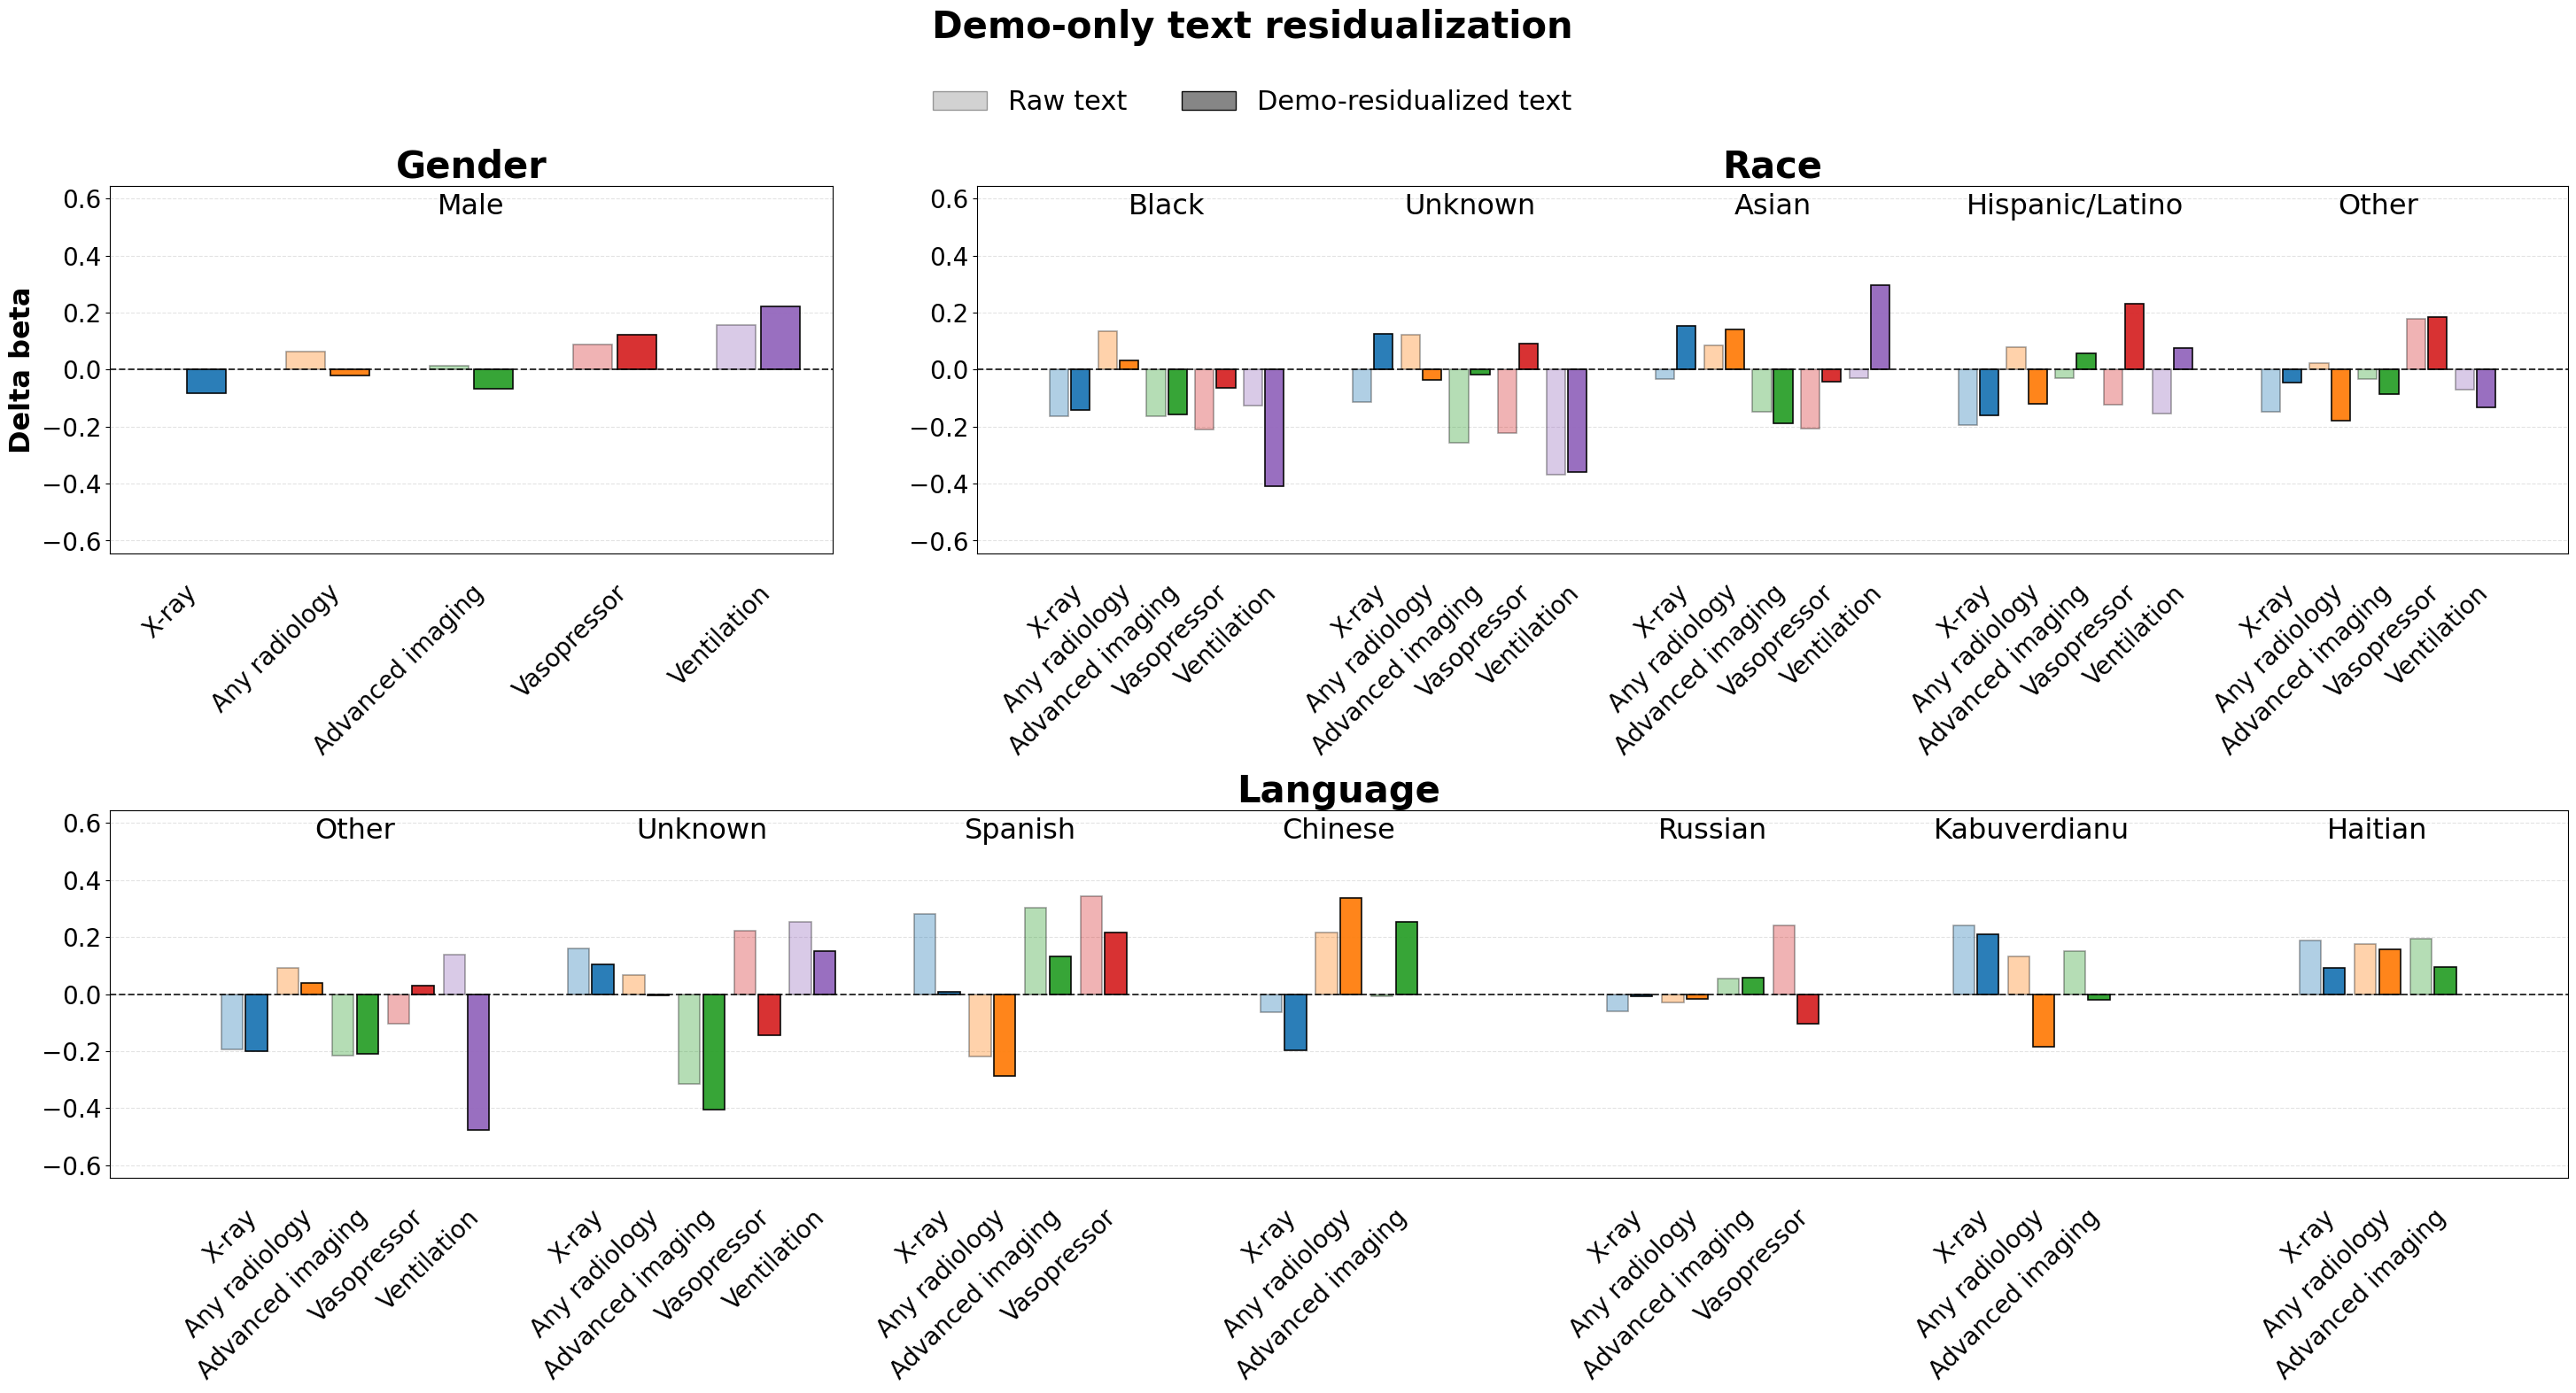


Demo-only residualization summary
               outcome group_var  n_levels  median_abs_delta_beta_raw  median_abs_delta_beta_alt  median_alt_share_beta  median_attenuation_beta  sign_same_beta_share   dataset
 time_to_pressor_hours    gender         2                   0.043565                   0.061503               1.411753                -0.411753              1.000000   pressor
 time_to_pressor_hours  language         5                   0.222171                   0.104484               0.533611                 0.466389              0.400000   pressor
 time_to_pressor_hours      race         6                   0.192635                   0.078208               0.410891                 0.589109              0.666667   pressor
time_to_advanced_hours    gender         2                   0.006362                   0.034026               5.348291                -4.348291              0.500000 radiology
time_to_advanced_hours  language         8                   0.172049           

In [10]:
# Demo-only residualization: compare residualized-text shift with raw-text main shift.

residualization_shift = read_dataset_file("residualization_demo_only_shift.parquet")
residualization_summary = read_dataset_file("residualization_demo_only_shift_summary.parquet")
residualization_r2 = read_dataset_file("residualization_demo_only_r2.parquet")

if len(residualization_shift) > 0:
    plot_sensitivity_bar_comparison(
        residualization_shift,
        value_specs=[("Raw text", "delta_beta_raw"), ("Demo-residualized text", "delta_beta_resid")],
        title="Demo-only text residualization",
        ylabel="Delta beta",
    )

print_table(
    residualization_summary.sort_values(
        [c for c in ["dataset", "outcome", "group_var"] if c in residualization_summary.columns]
    ).reset_index(drop=True),
    "Demo-only residualization summary",
)
print_table(
    residualization_r2.sort_values(
        [c for c in ["dataset", "outcome"] if c in residualization_r2.columns]
    ).reset_index(drop=True),
    "Demo-only residualization R2",
)


In [11]:
# Demo-only residualization overall shift statistics.

if len(residualization_shift) > 0:
    residualization_shift_stats = add_main_delta(residualization_shift)
    demo_residualization_shift_details = print_sensitivity_shift_statistics(
        df=residualization_shift_stats,
        baseline_col="delta_beta_raw",
        sensitivity_col="delta_beta_resid",
        title="Demo-only residualization sensitivity",
    )



Demo-only residualization sensitivity

Demo-only residualization sensitivity: single overall shift summary
                           robustness  n_contrasts  n_variants  median_abs_gap  p90_abs_gap  max_abs_gap  sign_flip_rate  near_zero_baseline_rate  meaningful_sign_flip_rate  median_abs_gap_over_abs_baseline  median_attenuation_ratio  median_abs_gap_over_main_se  share_gap_gt_0_5se  share_gap_gt_1se  share_gap_gt_2se
Demo-only residualization sensitivity           72           1        0.068195     0.279879      0.61633        0.291667                 0.035088                   0.333333                          0.796629                    0.4122                      2.67704            0.824561           0.77193          0.561404


## Demographic leakage

In [12]:
# Demographic leakage test: print the leakage metrics only.

leakage = read_dataset_file("residualization_demo_only_leakage.parquet")

sort_cols = [c for c in ["dataset", "outcome", "target", "feature_set"] if c in leakage.columns]
print_table(
    leakage.sort_values(sort_cols).reset_index(drop=True) if sort_cols else leakage,
    "Demographic leakage metrics",
    max_rows=300,
)


Demographic leakage metrics
  dataset                outcome   target  log_loss_structured  log_loss_structured_plus_raw_text  log_loss_structured_plus_resid_text  balanced_acc_structured  balanced_acc_structured_plus_raw_text  balanced_acc_structured_plus_resid_text
  pressor  time_to_pressor_hours   gender             0.661444                           0.660134                             0.617214                 0.594116                               0.594446                                 0.677932
  pressor  time_to_pressor_hours language             0.402163                           0.401322                             0.351634                 0.200300                               0.200284                                 0.205805
  pressor  time_to_pressor_hours     race             1.040821                           1.032793                             0.708672                 0.173100                               0.173934                                 0.292664
radiology t

## Conditional residualization

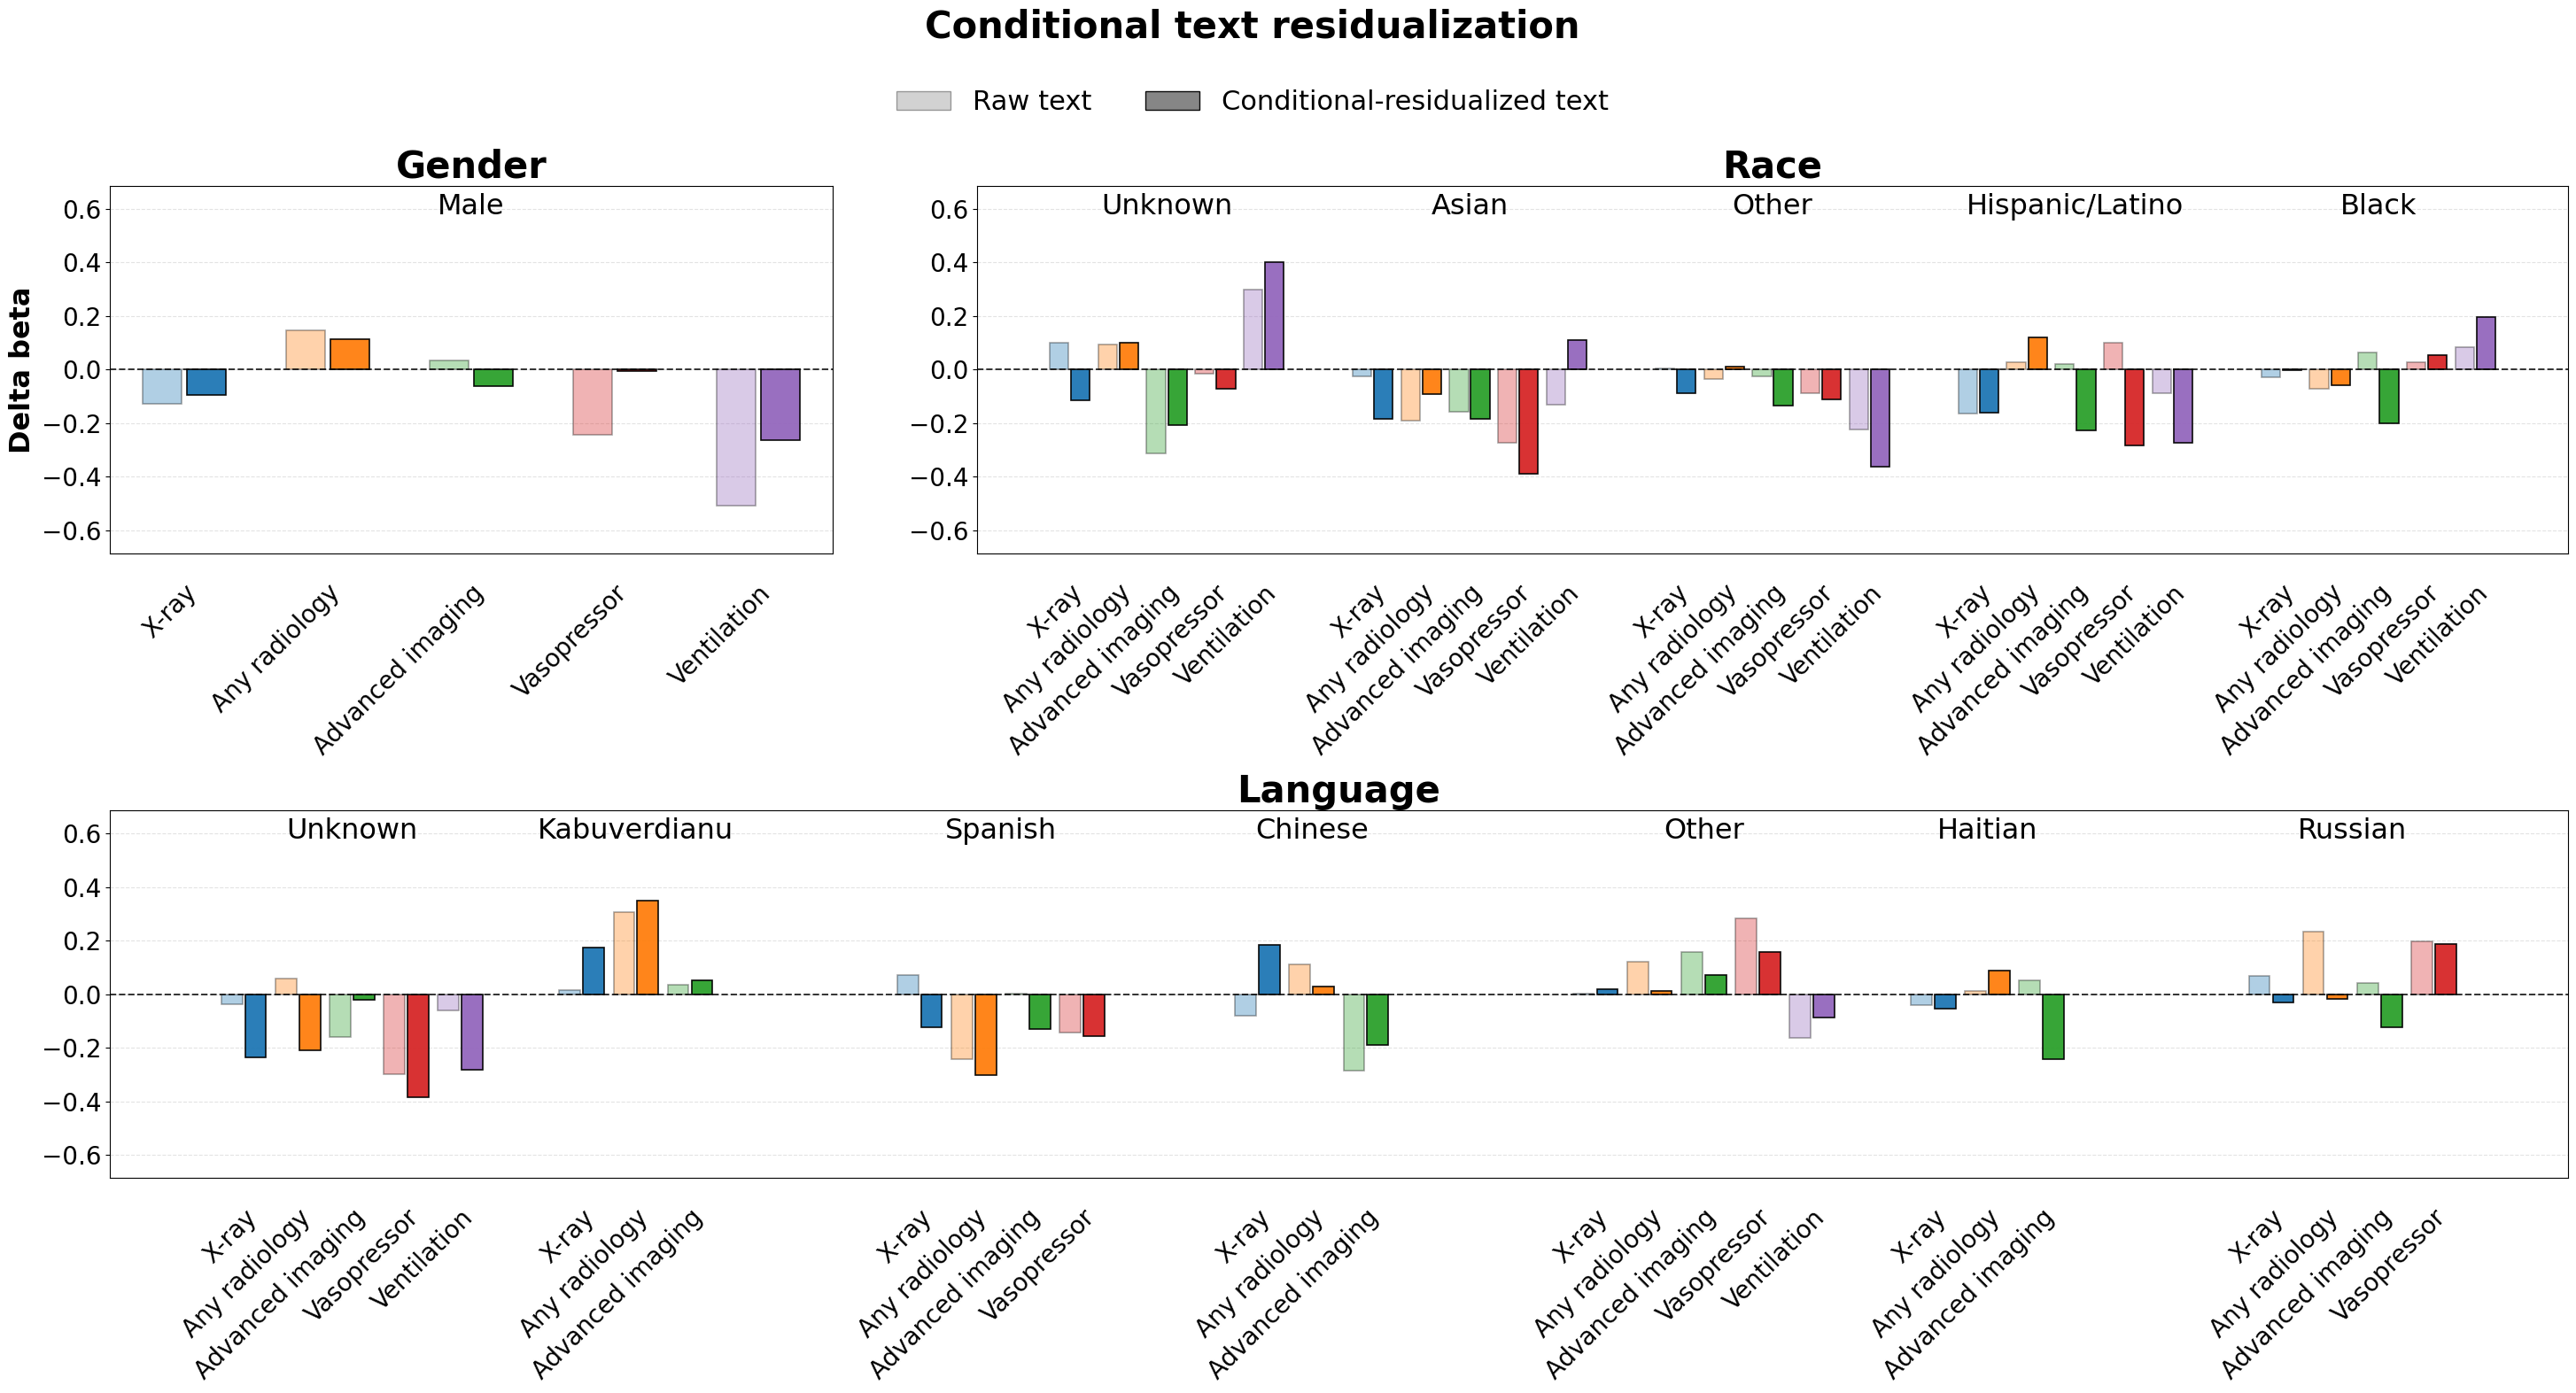


Conditional residualization summary
               outcome group_var  n_levels  median_abs_delta_beta_raw  median_abs_delta_beta_alt  median_alt_share_beta  median_attenuation_beta  sign_same_beta_share   dataset
 time_to_pressor_hours    gender         2                   0.121485                   0.002262               0.018618                 0.981382              1.000000   pressor
 time_to_pressor_hours  language         5                   0.196548                   0.156061               1.019932                -0.019932              1.000000   pressor
 time_to_pressor_hours      race         6                   0.058630                   0.092551               1.895732                -0.895732              0.833333   pressor
time_to_advanced_hours    gender         2                   0.017376                   0.030964               1.782009                -0.782009              0.500000 radiology
time_to_advanced_hours  language         8                   0.046004         

In [13]:
# Conditional residualization: compare conditionally residualized-text shift with raw-text main shift.

conditional_shift = read_dataset_file("conditional_residualization_shift.parquet")
conditional_summary = read_dataset_file("conditional_residualization_shift_summary.parquet")
conditional_r2 = read_dataset_file("conditional_residualization_r2.parquet")

if len(conditional_shift) > 0:
    plot_sensitivity_bar_comparison(
        conditional_shift,
        value_specs=[("Raw text", "delta_beta_raw"), ("Conditional-residualized text", "delta_beta_condresid")],
        title="Conditional text residualization",
        ylabel="Delta beta",
    )

print_table(
    conditional_summary.sort_values(
        [c for c in ["dataset", "outcome", "group_var"] if c in conditional_summary.columns]
    ).reset_index(drop=True),
    "Conditional residualization summary",
)
print_table(
    conditional_r2.sort_values(
        [c for c in ["dataset", "outcome"] if c in conditional_r2.columns]
    ).reset_index(drop=True),
    "Conditional residualization R2",
)


In [14]:
# Conditional residualization overall shift statistics.

if len(conditional_shift) > 0:
    conditional_shift_stats = add_main_delta(conditional_shift)
    conditional_residualization_shift_details = print_sensitivity_shift_statistics(
        df=conditional_shift_stats,
        baseline_col="delta_beta_raw",
        sensitivity_col="delta_beta_condresid",
        title="Conditional residualization sensitivity",
    )



Conditional residualization sensitivity

Conditional residualization sensitivity: single overall shift summary
                             robustness  n_contrasts  n_variants  median_abs_gap  p90_abs_gap  max_abs_gap  sign_flip_rate  near_zero_baseline_rate  meaningful_sign_flip_rate  median_abs_gap_over_abs_baseline  median_attenuation_ratio  median_abs_gap_over_main_se  share_gap_gt_0_5se  share_gap_gt_1se  share_gap_gt_2se
Conditional residualization sensitivity           72           1        0.083243     0.243956     0.381356        0.222222                 0.140351                    0.22807                          0.907901                  0.739215                     2.423996            0.859649           0.77193          0.561404


## Objective complaint subset

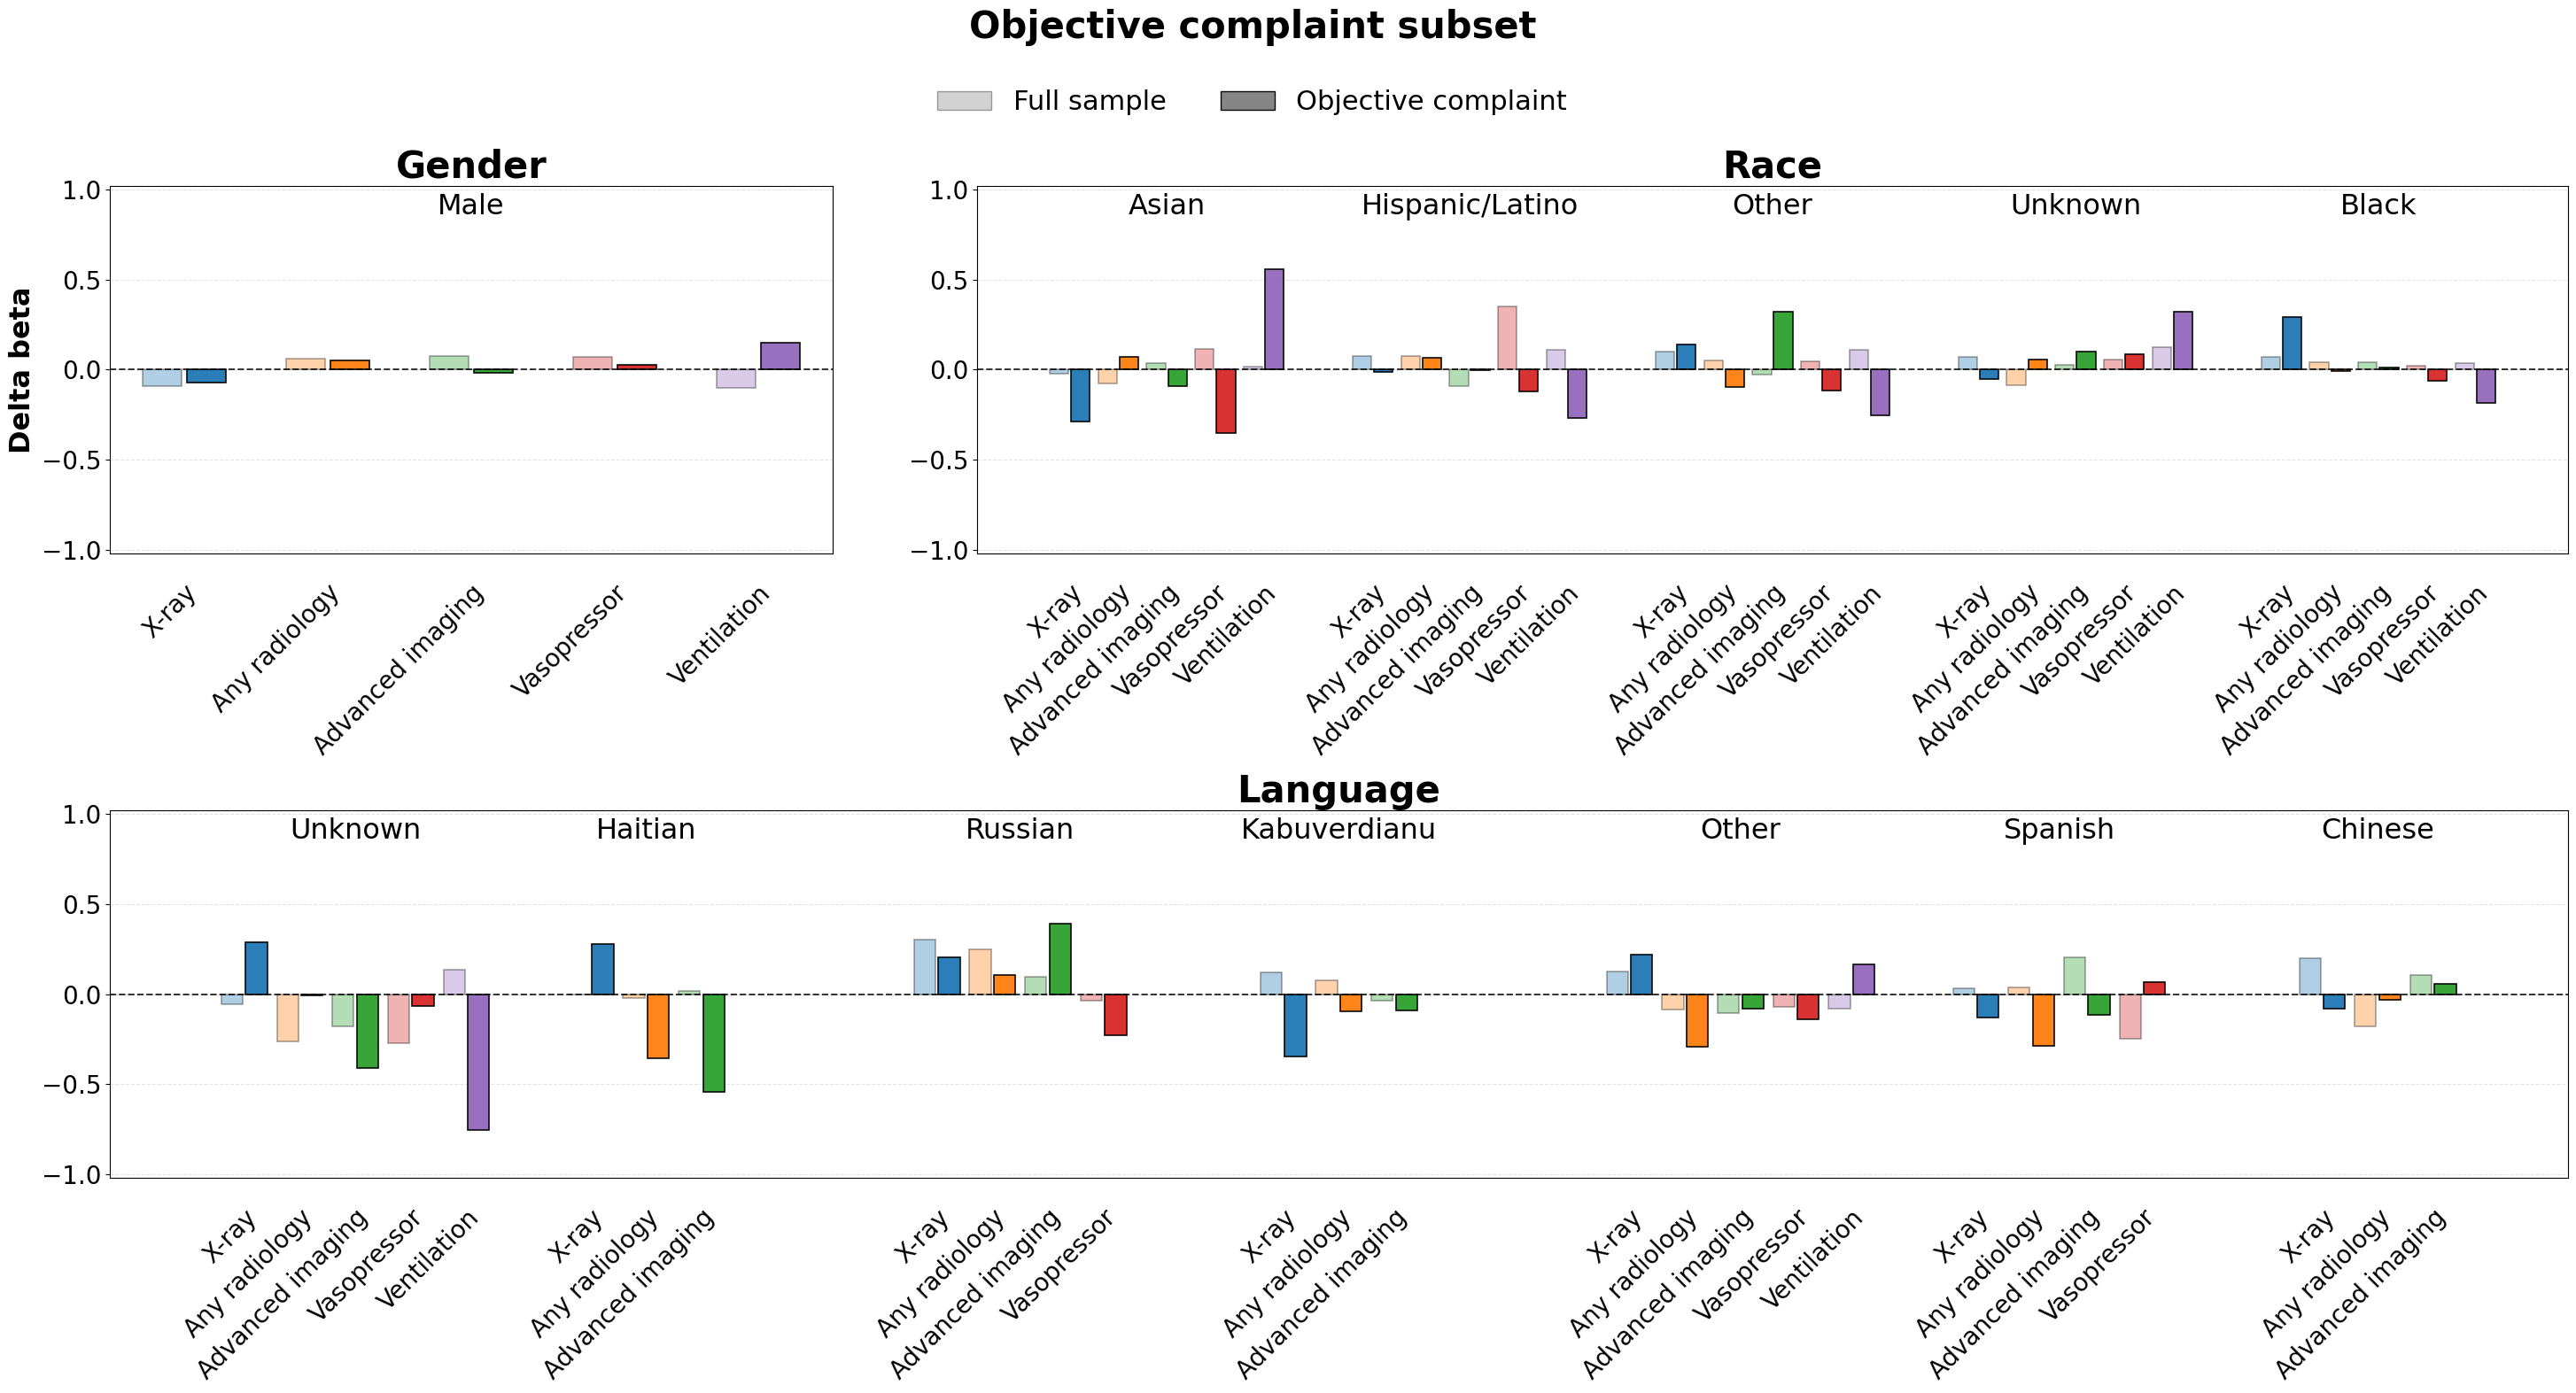


Objective complaint summary
               outcome group_var  n_levels  median_abs_shift_objective_beta  median_abs_shift_full_beta  median_objective_over_full_beta_ratio  same_direction_beta_vs_full_share  tau  n_risk  n_event   dataset
 time_to_pressor_hours    gender         2                         0.014192                    0.034091                               0.416297                           1.000000  2.0     917      204   pressor
 time_to_pressor_hours  language         5                         0.066276                    0.069140                               1.128745                           0.800000  2.0     917      204   pressor
 time_to_pressor_hours      race         6                         0.102108                    0.050914                               2.494056                           0.333333  2.0     917      204   pressor
time_to_advanced_hours    gender         2                         0.007817                    0.038104                            

In [15]:
# Objective-complaint subset: compare objective-complaint shift with the main full-sample shift.

objective_vs_full = read_dataset_file("objective_complaint_vs_full.parquet")
objective_summary = read_dataset_file("objective_complaint_summary.parquet")

if len(objective_vs_full) > 0:
    plot_sensitivity_bar_comparison(
        objective_vs_full,
        value_specs=[("Full sample", "delta_beta_full"), ("Objective complaint", "delta_beta")],
        title="Objective complaint subset",
        ylabel="Delta beta",
    )

print_table(
    objective_summary.sort_values(
        [c for c in ["dataset", "outcome", "group_var"] if c in objective_summary.columns]
    ).reset_index(drop=True),
    "Objective complaint summary",
)


In [16]:
# Objective-complaint subset overall shift statistics.

if len(objective_vs_full) > 0:
    objective_shift_stats = add_main_delta(objective_vs_full)
    objective_complaint_shift_details = print_sensitivity_shift_statistics(
        df=objective_shift_stats,
        baseline_col="delta_beta_full",
        sensitivity_col="delta_beta",
        title="Objective complaint subset sensitivity",
    )



Objective complaint subset sensitivity

Objective complaint subset sensitivity: single overall shift summary
                            robustness  n_contrasts  n_variants  median_abs_gap  p90_abs_gap  max_abs_gap  sign_flip_rate  near_zero_baseline_rate  meaningful_sign_flip_rate  median_abs_gap_over_abs_baseline  median_attenuation_ratio  median_abs_gap_over_main_se  share_gap_gt_0_5se  share_gap_gt_1se  share_gap_gt_2se
Objective complaint subset sensitivity           72           1        0.134544     0.364771     0.890684        0.402778                 0.122807                   0.438596                          1.701306                 -0.171783                     3.028953            0.982456          0.964912           0.77193


## Transfer subgroup

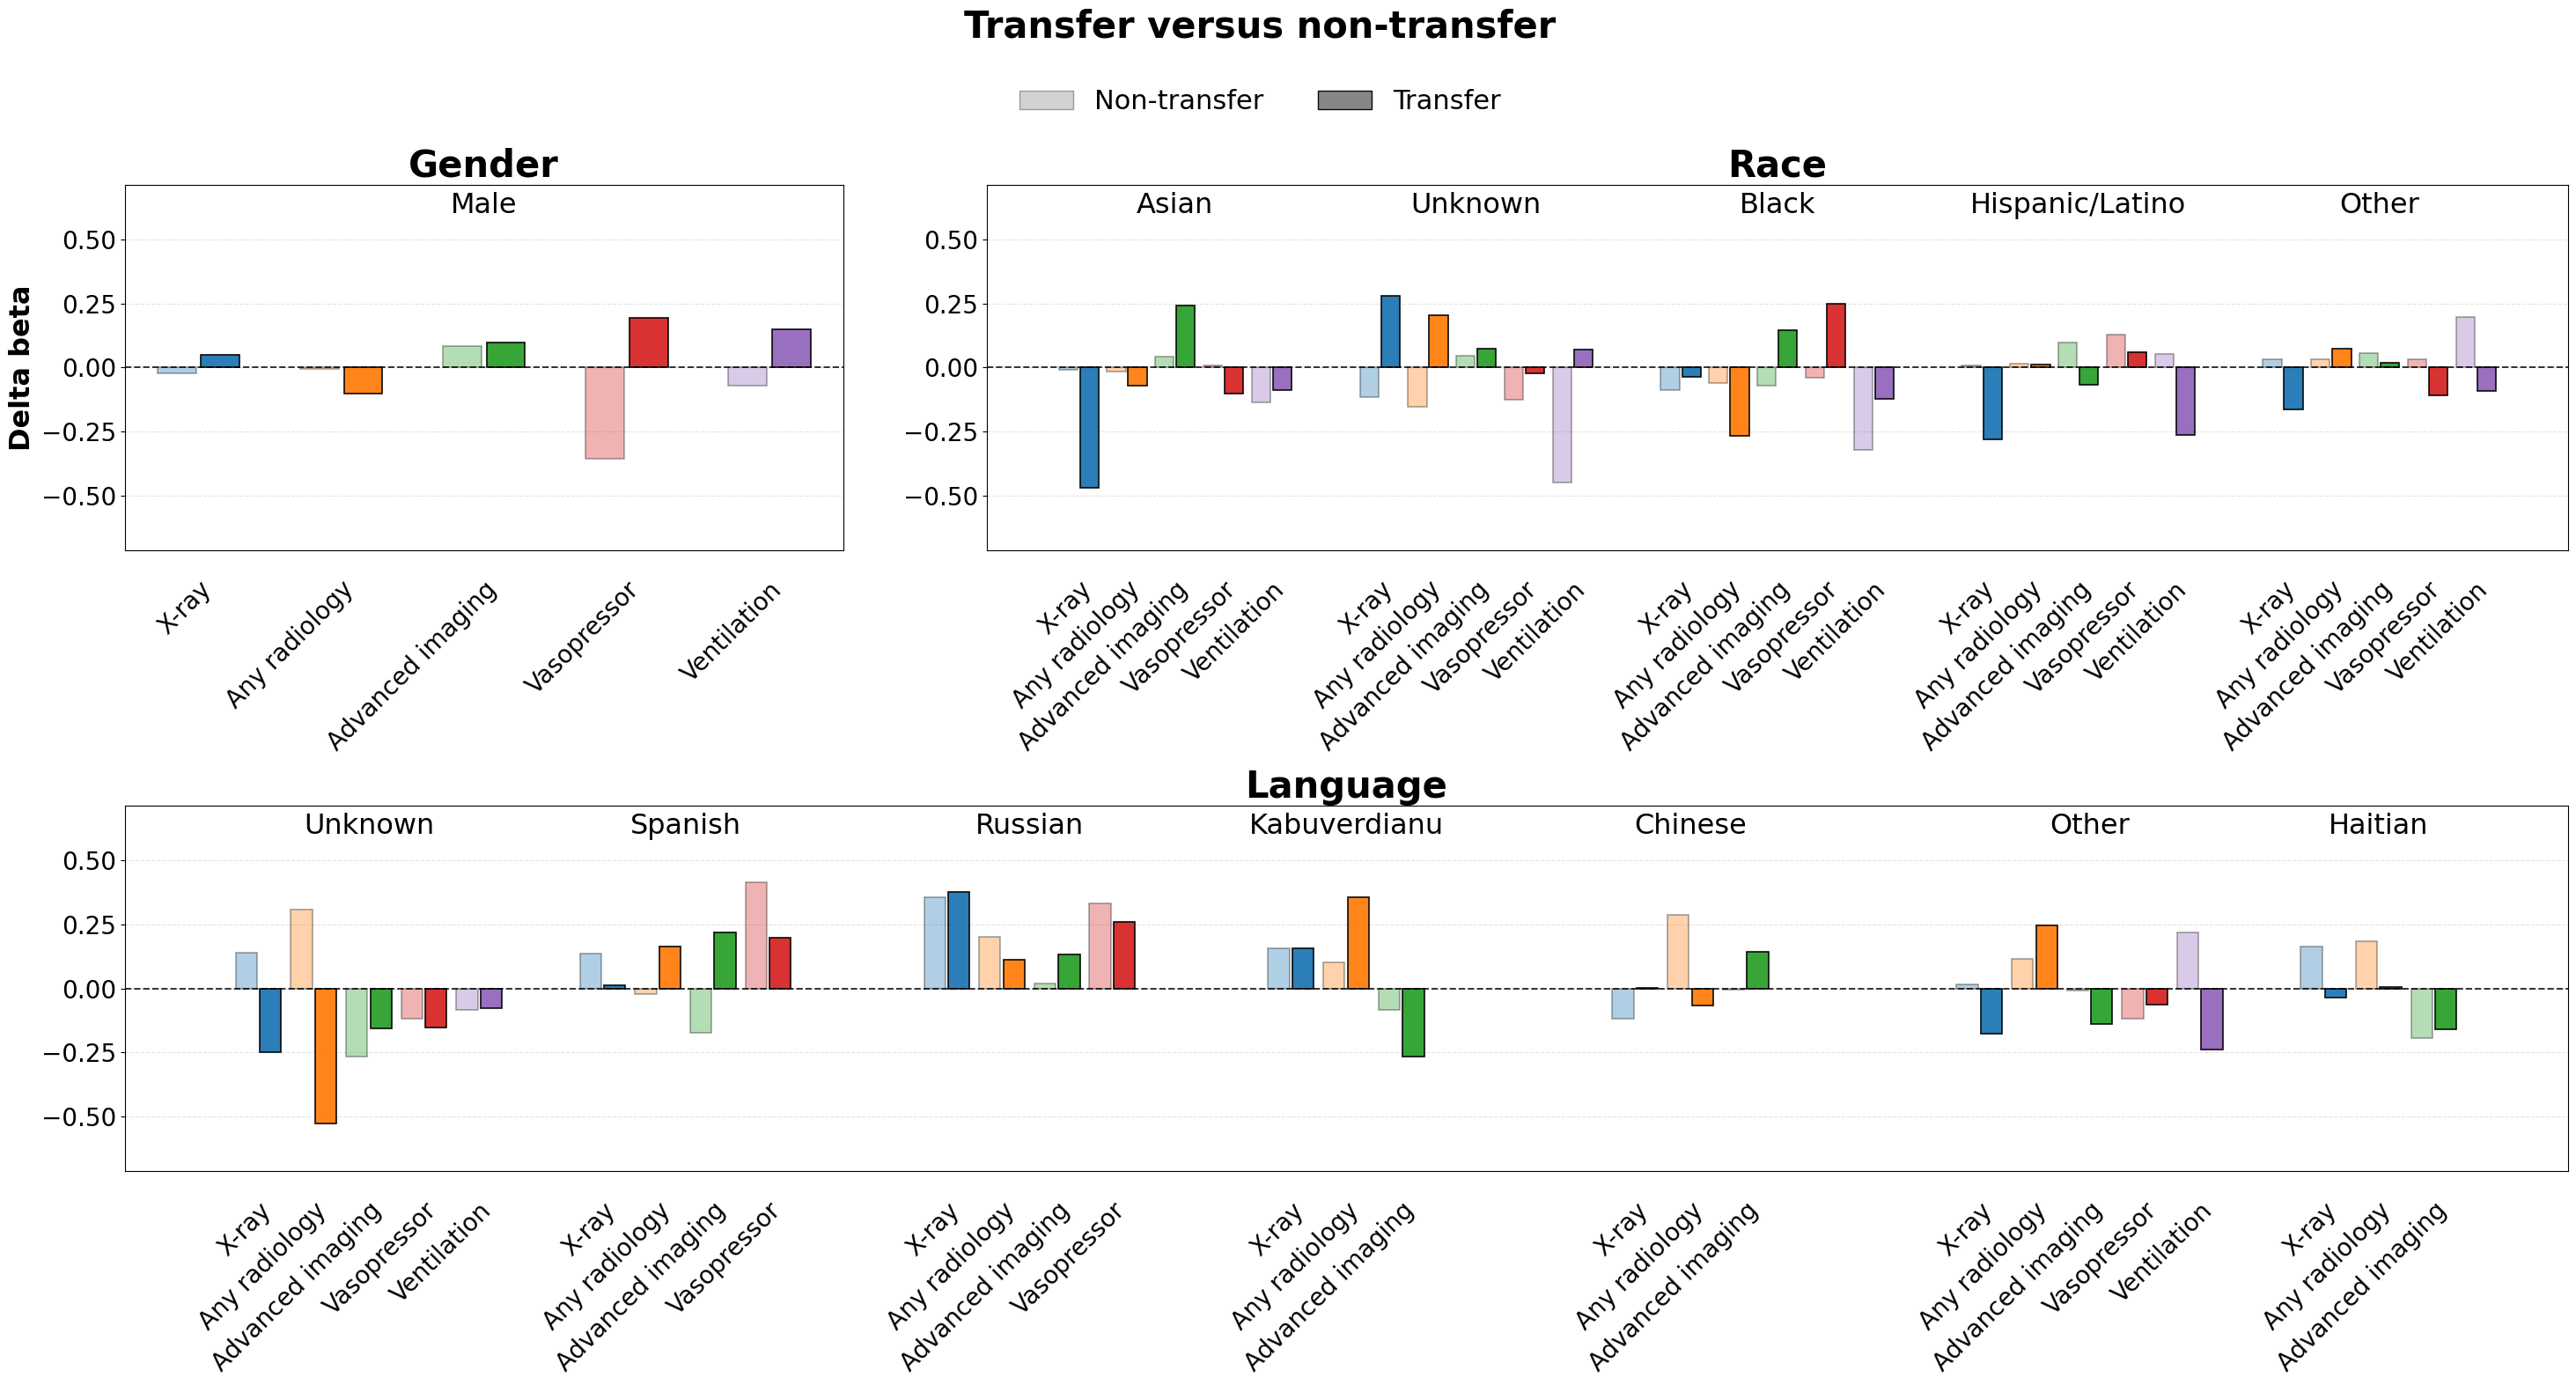


Transfer summary
               outcome group_var  n_levels  median_abs_shift_beta_non_transfer  median_abs_shift_beta_transfer  median_transfer_over_non_beta_ratio  same_direction_beta_share   dataset
 time_to_pressor_hours    gender         2                            0.178329                        0.097417                             0.546278                   0.500000   pressor
 time_to_pressor_hours  language         5                            0.119562                        0.151686                             0.665816                   1.000000   pressor
 time_to_pressor_hours      race         6                            0.035965                        0.080132                             3.367905                   0.500000   pressor
time_to_advanced_hours    gender         2                            0.041332                        0.048313                             1.168886                   1.000000 radiology
time_to_advanced_hours  language         8               

In [17]:
# Transfer subgroup: compare transfer with non-transfer.

transfer_shift = read_dataset_file("transfer_shift.parquet")
transfer_summary = read_dataset_file("transfer_shift_summary.parquet")
transfer_counts = read_dataset_file("transfer_subgroups_counts.parquet")

if len(transfer_shift) > 0:
    plot_sensitivity_bar_comparison(
        transfer_shift,
        value_specs=[("Non-transfer", "delta_beta_non_transfer"), ("Transfer", "delta_beta_transfer")],
        title="Transfer versus non-transfer",
        ylabel="Delta beta",
    )

print_table(
    transfer_summary.sort_values(
        [c for c in ["dataset", "outcome", "group_var"] if c in transfer_summary.columns]
    ).reset_index(drop=True),
    "Transfer summary",
)
print_table(
    transfer_counts.sort_values(
        [c for c in ["dataset", "subgroup", "outcome"] if c in transfer_counts.columns]
    ).reset_index(drop=True),
    "Transfer subgroup counts",
)


In [18]:
# Transfer subgroup overall heterogeneity statistics.

if len(transfer_shift) > 0:
    transfer_shift_stats = add_main_delta(transfer_shift)
    transfer_subgroup_shift_details = print_pairwise_heterogeneity_statistics(
        df=transfer_shift_stats,
        left_col="delta_beta_non_transfer",
        right_col="delta_beta_transfer",
        title="Transfer versus non-transfer subgroup heterogeneity",
    )



Transfer versus non-transfer subgroup heterogeneity

Transfer versus non-transfer subgroup heterogeneity: single overall subgroup-gap summary
                                           analysis  n_contrasts  median_abs_subgroup_gap  p90_abs_subgroup_gap  max_abs_subgroup_gap  median_abs_subgroup_gap_over_main_se  share_subgroup_gap_gt_0_5se  share_subgroup_gap_gt_1se  share_subgroup_gap_gt_2se
Transfer versus non-transfer subgroup heterogeneity           72                 0.108917              0.385218              0.835125                              3.582025                     0.912281                   0.859649                   0.701754


## Design diagnostics

In [19]:
# Design diagnostics: print main fitted-model diagnostics from the DAGJ refit pipeline.

diagnostics = read_dataset_path_map(
    lambda dataset, base: base / "delete_a_group_jackknife" / "jackknife_diagnostics.parquet"
)

if len(diagnostics) > 0:
    model_diag = diagnostics.copy()
    if "diagnostic_type" in model_diag.columns:
        model_diag = model_diag.loc[model_diag["diagnostic_type"].astype(str).eq("delete_group_model_fit")].copy()

    group_cols = [c for c in ["dataset", "outcome", "family_var", "scheme"] if c in model_diag.columns]
    metric_cols = [
        "n_rows_positive_weight",
        "n_train_rows_positive_weight",
        "n_val_rows_positive_weight",
        "n_train_event_positive_weight",
        "n_val_event_positive_weight",
        "effective_sample_size",
        "weight_p01",
        "weight_p50",
        "weight_p99",
        "min_val_loss",
        "final_val_loss",
    ]

    agg_map = {}
    for col in metric_cols:
        if col in model_diag.columns:
            agg_map[f"{col}_min"] = (col, "min")
            agg_map[f"{col}_median"] = (col, "median")
            agg_map[f"{col}_max"] = (col, "max")

    design_summary = model_diag.groupby(group_cols, as_index=False).agg(**agg_map)
    print_table(
        design_summary.sort_values(group_cols).reset_index(drop=True),
        "DAGJ design diagnostics summary",
        max_rows=300,
    )

    skipped = diagnostics.copy()
    if "diagnostic_type" in skipped.columns:
        skipped = skipped.loc[skipped["diagnostic_type"].astype(str).eq("delete_group_skipped")].copy()
    print_table(
        skipped.sort_values([c for c in ["dataset", "outcome", "family_var", "scheme", "skip_reason"] if c in skipped.columns]).reset_index(drop=True),
        "Skipped DAGJ refit diagnostics",
        max_rows=120,
    )
else:
    print_table(diagnostics, "DAGJ design diagnostics summary")


DAGJ design diagnostics summary
  dataset                outcome family_var               scheme  n_rows_positive_weight_min  n_rows_positive_weight_median  n_rows_positive_weight_max  n_train_rows_positive_weight_min  n_train_rows_positive_weight_median  n_train_rows_positive_weight_max  n_val_rows_positive_weight_min  n_val_rows_positive_weight_median  n_val_rows_positive_weight_max  n_train_event_positive_weight_min  n_train_event_positive_weight_median  n_train_event_positive_weight_max  n_val_event_positive_weight_min  n_val_event_positive_weight_median  n_val_event_positive_weight_max  effective_sample_size_min  effective_sample_size_median  effective_sample_size_max  weight_p01_min  weight_p01_median  weight_p01_max  weight_p50_min  weight_p50_median  weight_p50_max  weight_p99_min  weight_p99_median  weight_p99_max  min_val_loss_min  min_val_loss_median  min_val_loss_max  final_val_loss_min  final_val_loss_median  final_val_loss_max
  pressor  time_to_pressor_hours     gender 

## Fixed-weighting sensitivity

In [20]:
# Fixed-weighting overall shift statistics.

if "fixed_weighting_all" in globals() and len(fixed_weighting_all) > 0:
    fixed_weighting_stats = add_main_delta(
        fixed_weighting_all.loc[
            fixed_weighting_all["weight_mode"].isin(["fixed_text_weight", "fixed_structured_weight"])
        ].copy()
    )
    fixed_weighting_shift_details = print_sensitivity_shift_statistics(
        df=fixed_weighting_stats,
        baseline_col="delta_beta_scheme_specific_current",
        sensitivity_col="delta_beta",
        title="Fixed-weighting sensitivity",
        strata_cols=["weight_mode"],
    )



Fixed-weighting sensitivity

Fixed-weighting sensitivity: single overall shift summary
                 robustness  n_contrasts  n_variants  median_abs_gap  p90_abs_gap  max_abs_gap  sign_flip_rate  near_zero_baseline_rate  meaningful_sign_flip_rate  median_abs_gap_over_abs_baseline  median_attenuation_ratio  median_abs_gap_over_main_se  share_gap_gt_0_5se  share_gap_gt_1se  share_gap_gt_2se
Fixed-weighting sensitivity          144           2    1.261440e-10     0.023696     0.082092             0.0                 0.122807                        0.0                          0.003149                       1.0                     0.004393            0.140351           0.04386               0.0


## Overall robustness summary


In [21]:
# One-row overall summaries across all plotted checks.
all_sensitivity_overall_summary = print_all_sensitivity_overall_summaries()
all_heterogeneity_overall_summary = print_all_heterogeneity_overall_summaries()



Overall sensitivity summary across robustness checks

All robustness checks: single-row overall summaries
                             robustness  n_contrasts  n_variants  median_abs_gap  p90_abs_gap  max_abs_gap  sign_flip_rate  near_zero_baseline_rate  meaningful_sign_flip_rate  median_abs_gap_over_abs_baseline  median_attenuation_ratio  median_abs_gap_over_main_se  share_gap_gt_0_5se  share_gap_gt_1se  share_gap_gt_2se
  Demo-only residualization sensitivity           72           1    6.819485e-02     0.279879     0.616330        0.291667                 0.035088                   0.333333                          0.796629                  0.412200                     2.677040            0.824561          0.771930          0.561404
Conditional residualization sensitivity           72           1    8.324313e-02     0.243956     0.381356        0.222222                 0.140351                   0.228070                          0.907901                  0.739215                   

## Basic data summaries

In [22]:
# Basic analytic data summaries for three datasets and five outcomes.

BASIC_DATASETS = {
    "radiology": {
        "path": MAIN / "shared" / "radiology" / "radiology_analytic_imputed.parquet",
        "id_cols": ["subject_id", "hadm_id", "ed_stay_id"],
        "outcomes": [
            {"outcome": "time_to_any_rad_hours", "time_col": "time_to_any_rad_hours", "tau": 6.0},
            {"outcome": "time_to_advanced_hours", "time_col": "time_to_advanced_hours", "tau": 6.0},
            {"outcome": "time_to_xray_hours", "time_col": "time_to_xray_hours", "tau": 6.0},
        ],
        "numeric_cols": [
            "anchor_age", "anchor_age_sq", "acuity", "temperature", "heartrate", "resprate",
            "o2sat", "sbp", "dbp", "pain",
        ],
        "categorical_cols": ["gender", "race", "language", "insurance", "arrival_transport", "chiefcomplaint", "cc_missing"],
    },
    "pressor": {
        "path": MAIN / "shared" / "pressor" / "pressor_analytic_imputed.parquet",
        "id_cols": ["subject_id", "hadm_id", "stay_id"],
        "outcomes": [
            {"outcome": "time_to_pressor_hours", "time_col": "time_to_pressor_hours", "tau": 2.0},
        ],
        "numeric_cols": [
            "anchor_age", "anchor_age_sq", "trigger_value", "time_since_icu_admission_hours",
            "temp_last", "hr_last", "rr_last", "spo2_last", "sbp_last", "dbp_last", "map_last",
            "lactate_last", "creatinine_last", "wbc_last", "platelets_last", "sodium_last",
            "potassium_last",
        ],
        "categorical_cols": ["gender", "race", "language", "insurance", "first_careunit", "last_careunit", "chiefcomplaint", "cc_missing"],
    },
    "vent": {
        "path": MAIN / "shared" / "vent" / "vent_analytic_imputed.parquet",
        "id_cols": ["subject_id", "hadm_id", "stay_id"],
        "outcomes": [
            {"outcome": "time_to_vent_hours", "time_col": "time_to_vent_hours", "tau": 6.0},
        ],
        "numeric_cols": [
            "anchor_age", "anchor_age_sq", "trigger_value", "time_since_icu_admission_hours",
            "temp_last", "hr_last", "rr_last", "spo2_last", "sbp_last", "dbp_last", "map_last",
            "lactate_last", "creatinine_last", "wbc_last", "platelets_last", "sodium_last",
            "potassium_last",
        ],
        "categorical_cols": ["gender", "race", "language", "insurance", "first_careunit", "last_careunit", "chiefcomplaint", "cc_missing"],
    },
}


def survival_target_summary(df: pd.DataFrame, time_col: str, tau: float):
    t = pd.to_numeric(df[time_col], errors="coerce")
    active_at_t0 = t.notna() & (t <= 0)
    in_risk = ~active_at_t0
    t_risk = t.loc[in_risk]
    event = t_risk.notna() & (t_risk > 0) & (t_risk <= tau)
    duration = np.where(event.to_numpy(), t_risk.to_numpy(dtype=float), float(tau))
    return in_risk, event.to_numpy(dtype=np.int8), duration.astype(float)


basic_count_rows = []
numeric_rows = []
categorical_rows = []

for dataset, cfg in BASIC_DATASETS.items():
    df = pd.read_parquet(cfg["path"]).copy()

    for outcome_cfg in cfg["outcomes"]:
        outcome = outcome_cfg["outcome"]
        time_col = outcome_cfg["time_col"]
        tau = float(outcome_cfg["tau"])

        in_risk, event, duration = survival_target_summary(df, time_col, tau)
        risk_df = df.loc[in_risk].copy()

        count_row = {
            "dataset": dataset,
            "outcome": outcome,
            "source_rows": int(len(df)),
            "n_risk": int(in_risk.sum()),
            "n_event": int(event.sum()),
            "event_rate": float(event.mean()) if len(event) > 0 else np.nan,
            "tau_hours": tau,
            "duration_min": float(np.min(duration)) if len(duration) > 0 else np.nan,
            "duration_max": float(np.max(duration)) if len(duration) > 0 else np.nan,
            "duration_mean": float(np.mean(duration)) if len(duration) > 0 else np.nan,
            "duration_median": float(np.median(duration)) if len(duration) > 0 else np.nan,
        }
        for col in cfg["id_cols"]:
            if col in risk_df.columns:
                count_row[f"n_unique_{col}"] = int(risk_df[col].nunique())
        basic_count_rows.append(count_row)

        for col in cfg["numeric_cols"] + [time_col]:
            if col not in risk_df.columns:
                continue
            x = pd.to_numeric(risk_df[col], errors="coerce")
            numeric_rows.append({
                "dataset": dataset,
                "outcome": outcome,
                "variable": col,
                "n_risk": int(len(risk_df)),
                "n_nonmissing": int(x.notna().sum()),
                "missing_rate": float(x.isna().mean()),
                "min": float(x.min()),
                "max": float(x.max()),
                "mean": float(x.mean()),
                "median": float(x.median()),
                "std": float(x.std()),
            })

        for col in cfg["categorical_cols"]:
            if col not in risk_df.columns:
                continue
            s = risk_df[col].astype("string")
            vc = s.value_counts(dropna=False)
            top_level = str(vc.index[0]) if len(vc) > 0 else None
            top_n = int(vc.iloc[0]) if len(vc) > 0 else 0
            categorical_rows.append({
                "dataset": dataset,
                "outcome": outcome,
                "variable": col,
                "n_risk": int(len(risk_df)),
                "n_nonmissing": int(s.notna().sum()),
                "missing_rate": float(s.isna().mean()),
                "n_unique_nonmissing": int(s.nunique()),
                "top_level": top_level,
                "top_n": top_n,
                "top_pct": float(top_n / len(risk_df)) if len(risk_df) > 0 else np.nan,
            })

basic_counts = pd.DataFrame(basic_count_rows)
numeric_summary = pd.DataFrame(numeric_rows)
categorical_summary = pd.DataFrame(categorical_rows)

print_table(
    basic_counts.sort_values(["dataset", "outcome"]).reset_index(drop=True),
    "Basic outcome-level dataset counts",
    max_rows=50,
)
print_table(
    numeric_summary.sort_values(["dataset", "outcome", "variable"]).reset_index(drop=True),
    "Outcome-level numeric variable summary",
    max_rows=500,
)
print_table(
    categorical_summary.sort_values(["dataset", "outcome", "variable"]).reset_index(drop=True),
    "Outcome-level categorical variable summary",
    max_rows=500,
)


Basic outcome-level dataset counts
  dataset                outcome  source_rows  n_risk  n_event  event_rate  tau_hours  duration_min  duration_max  duration_mean  duration_median  n_unique_subject_id  n_unique_hadm_id  n_unique_ed_stay_id  n_unique_stay_id
  pressor  time_to_pressor_hours        69223   69223    15242    0.220187        2.0      0.016667           2.0       1.669496         2.000000                50281             63387                  NaN           69223.0
radiology time_to_advanced_hours       203016  203016    55903    0.275363        6.0      0.015000           6.0       4.824828         6.000000               107391            202441             203016.0               NaN
radiology  time_to_any_rad_hours       203016  203016   117540    0.578969        6.0      0.010556           6.0       3.354017         2.878611               107391            202441             203016.0               NaN
radiology     time_to_xray_hours       203016  203016    86845    0.

In [26]:
demo_rows = []

for dataset, cfg in BASIC_DATASETS.items():
    df = pd.read_parquet(cfg["path"])

    for col in ["race", "language", "gender"]:
        if col not in df.columns:
            continue

        counts = (
            df[col]
            .value_counts(dropna=False)
            .rename_axis("level")
            .reset_index(name="count")
        )

        counts["dataset"] = dataset
        counts["variable"] = col
        demo_rows.append(counts)

demographic_counts = pd.concat(demo_rows, ignore_index=True)

demographic_counts = demographic_counts[
    ["dataset", "variable", "level", "count"]
].sort_values(
    ["dataset", "variable", "count"],
    ascending=[True, True, False],
).reset_index(drop=True)

print_table(
    demographic_counts,
    "Dataset-level demographic counts",
    max_rows=1000,
)


Dataset-level demographic counts
  dataset variable           level  count
  pressor   gender               M  37732
  pressor   gender               F  31491
  pressor language         English  62322
  pressor language           Other   3470
  pressor language         Spanish   2007
  pressor language         Russian   1087
  pressor language         Unknown    337
  pressor     race           White  47125
  pressor     race         Unknown   8095
  pressor     race           Black   6690
  pressor     race           Other   2860
  pressor     race Hispanic/Latino   2448
  pressor     race           Asian   2005
radiology   gender               F 102354
radiology   gender               M 100662
radiology language         English 181615
radiology language         Spanish   7364
radiology language           Other   4478
radiology language         Russian   3488
radiology language         Chinese   2866
radiology language    Kabuverdianu   1994
radiology language         Haitian   1069


In [53]:
import numpy as np
import pandas as pd
from pathlib import Path

ROOT = Path(".")
MAIN = ROOT / "main"

MAIN_DIAG_PATHS = {
    "radiology": MAIN / "radiology" / "main" / "radiology_weighted_diagnostics.parquet",
    "pressor": MAIN / "icu" / "pressor" / "main" / "pressor_weighted_diagnostics.parquet",
    "vent": MAIN / "icu" / "vent" / "main" / "vent_weighted_diagnostics.parquet",
}

DAGJ_DIAG_PATHS = {
    "radiology": MAIN / "radiology" / "delete_a_group_jackknife" / "jackknife_diagnostics.parquet",
    "pressor": MAIN / "icu" / "pressor" / "delete_a_group_jackknife" / "jackknife_diagnostics.parquet",
    "vent": MAIN / "icu" / "vent" / "delete_a_group_jackknife" / "jackknife_diagnostics.parquet",
}

OUTCOME_LABEL = {
    "time_to_xray_hours": "X-ray",
    "time_to_any_rad_hours": "Any radiology",
    "time_to_advanced_hours": "Advanced imaging",
    "time_to_pressor_hours": "Vasopressor",
    "time_to_vent_hours": "Ventilation",
}

def existing_cols(df, cols):
    return [c for c in cols if c in df.columns]

def print_table(title, df, max_rows=300):
    print("\n" + "=" * 140)
    print(title)
    print("=" * 140)
    print(df.head(max_rows).to_string(index=False))
    if len(df) > max_rows:
        print(f"... printed {max_rows} of {len(df)} rows")

main_diag = pd.concat(
    [
        pd.read_parquet(path).assign(dataset=dataset)
        for dataset, path in MAIN_DIAG_PATHS.items()
    ],
    ignore_index=True,
)

model_fit = main_diag.loc[
    main_diag["diagnostic_type"].astype(str).eq("model_fit")
].copy()

family_fit = main_diag.loc[
    main_diag["diagnostic_type"].astype(str).eq("family_weight_fit")
].copy()

model_fit["outcome_label"] = model_fit["outcome"].map(OUTCOME_LABEL).fillna(model_fit["outcome"])
family_fit["outcome_label"] = family_fit["outcome"].map(OUTCOME_LABEL).fillna(family_fit["outcome"])

model_fit["ess_over_n"] = model_fit["effective_sample_size"] / model_fit["n_rows"]
model_fit["weight_p99_over_p50"] = model_fit["weight_p99"] / model_fit["weight_p50"]
model_fit["weight_max_over_p50"] = model_fit["weight_max"] / model_fit["weight_p50"]

five_outcome_model_performance = (
    model_fit.loc[
        :,
        existing_cols(
            model_fit,
            [
                "dataset",
                "outcome",
                "outcome_label",
                "family_var",
                "scheme",
                "trim_label",
                "n_rows",
                "n_event",
                "n_demo_cols",
                "n_text_cols",
                "cindex_train_weighted",
                "cindex_train_unweighted",
                "cindex_val_weighted",
                "cindex_val_unweighted",
                "best_val_loss",
                "best_epoch",
                "n_epoch_run",
            ],
        ),
    ]
    .sort_values(existing_cols(model_fit, ["outcome_label", "family_var", "scheme"]))
    .reset_index(drop=True)
)

five_outcome_model_performance_summary = (
    five_outcome_model_performance
    .groupby(["outcome_label", "scheme"], as_index=False)
    .agg(
        n_family_models=("family_var", "nunique"),
        min_val_cindex_weighted=("cindex_val_weighted", "min"),
        median_val_cindex_weighted=("cindex_val_weighted", "median"),
        max_val_cindex_weighted=("cindex_val_weighted", "max"),
        min_train_cindex_weighted=("cindex_train_weighted", "min"),
        median_train_cindex_weighted=("cindex_train_weighted", "median"),
        max_train_cindex_weighted=("cindex_train_weighted", "max"),
        median_best_val_loss=("best_val_loss", "median"),
        median_best_epoch=("best_epoch", "median"),
        median_n_epoch_run=("n_epoch_run", "median"),
    )
    .sort_values(["outcome_label", "scheme"])
    .reset_index(drop=True)
)

full_sample_overlap_ess = (
    model_fit.loc[
        :,
        existing_cols(
            model_fit,
            [
                "dataset",
                "outcome",
                "outcome_label",
                "family_var",
                "scheme",
                "trim_label",
                "n_rows",
                "n_event",
                "weight_min",
                "weight_p01",
                "weight_p50",
                "weight_p99",
                "weight_max",
                "weight_p99_over_p50",
                "weight_max_over_p50",
                "effective_sample_size",
                "ess_over_n",
                "cindex_val_weighted",
            ],
        ),
    ]
    .sort_values(existing_cols(model_fit, ["outcome_label", "family_var", "scheme"]))
    .reset_index(drop=True)
)

full_sample_overlap_summary = (
    full_sample_overlap_ess
    .groupby(["outcome_label", "family_var"], as_index=False)
    .agg(
        min_ess_over_n=("ess_over_n", "min"),
        median_ess_over_n=("ess_over_n", "median"),
        min_effective_sample_size=("effective_sample_size", "min"),
        median_effective_sample_size=("effective_sample_size", "median"),
        max_weight_p99_over_p50=("weight_p99_over_p50", "max"),
        max_weight_max_over_p50=("weight_max_over_p50", "max"),
        min_cindex_val_weighted=("cindex_val_weighted", "min"),
        median_cindex_val_weighted=("cindex_val_weighted", "median"),
        max_cindex_val_weighted=("cindex_val_weighted", "max"),
    )
    .sort_values(["outcome_label", "family_var"])
    .reset_index(drop=True)
)

if len(family_fit) > 0:
    if "n_family_levels" not in family_fit.columns and "n_levels" in family_fit.columns:
        family_fit["n_family_levels"] = family_fit["n_levels"]

    family_fit["family_weight_p99_over_p50"] = family_fit["family_weight_p99"] / family_fit["family_weight_p50"]
    family_fit["family_weight_max_over_p50"] = family_fit["family_weight_max"] / family_fit["family_weight_p50"]
    family_fit["family_prob_p01_over_p50"] = family_fit["family_prob_p01"] / family_fit["family_prob_p50"]
    family_fit["family_prob_min_over_p50"] = family_fit["family_prob_min"] / family_fit["family_prob_p50"]

    family_propensity_support = (
        family_fit.loc[
            :,
            existing_cols(
                family_fit,
                [
                    "dataset",
                    "outcome",
                    "outcome_label",
                    "family_var",
                    "scheme",
                    "n_rows",
                    "n_family_levels",
                    "family_class_observed",
                    "family_prob_min",
                    "family_prob_p01",
                    "family_prob_p50",
                    "family_prob_p99",
                    "family_prob_max",
                    "family_prob_p01_over_p50",
                    "family_prob_min_over_p50",
                    "family_weight_min",
                    "family_weight_p01",
                    "family_weight_p50",
                    "family_weight_p99",
                    "family_weight_max",
                    "family_weight_p99_over_p50",
                    "family_weight_max_over_p50",
                ],
            ),
        ]
        .sort_values(existing_cols(family_fit, ["outcome_label", "family_var", "scheme"]))
        .reset_index(drop=True)
    )

    family_propensity_summary = (
        family_fit
        .groupby(["outcome_label", "family_var"], as_index=False)
        .agg(
            min_family_prob_min=("family_prob_min", "min"),
            min_family_prob_p01=("family_prob_p01", "min"),
            median_family_prob_p50=("family_prob_p50", "median"),
            max_family_weight_p99_over_p50=("family_weight_p99_over_p50", "max"),
            max_family_weight_max_over_p50=("family_weight_max_over_p50", "max"),
            max_n_family_levels=("n_family_levels", "max"),
        )
        .sort_values(["outcome_label", "family_var"])
        .reset_index(drop=True)
    )
else:
    family_propensity_support = pd.DataFrame()
    family_propensity_summary = pd.DataFrame()

print_table("FIVE OUTCOME MODEL PERFORMANCE: DETAIL", five_outcome_model_performance)
print_table("FIVE OUTCOME MODEL PERFORMANCE: SUMMARY BY OUTCOME AND SCHEME", five_outcome_model_performance_summary)
print_table("FULL-SAMPLE OVERLAP WEIGHT / ESS: DETAIL", full_sample_overlap_ess)
print_table("FULL-SAMPLE OVERLAP WEIGHT / ESS: SUMMARY", full_sample_overlap_summary)
print_table("FAMILY PROPENSITY SUPPORT: DETAIL", family_propensity_support)
print_table("FAMILY PROPENSITY SUPPORT: SUMMARY", family_propensity_summary)

ROBUSTNESS_OUT = MAIN / "robustness_reader_exports"
ROBUSTNESS_OUT.mkdir(parents=True, exist_ok=True)

five_outcome_model_performance.to_csv(ROBUSTNESS_OUT / "five_outcome_model_performance.csv", index=False)
five_outcome_model_performance_summary.to_csv(ROBUSTNESS_OUT / "five_outcome_model_performance_summary.csv", index=False)
full_sample_overlap_ess.to_csv(ROBUSTNESS_OUT / "full_sample_overlap_ess.csv", index=False)
full_sample_overlap_summary.to_csv(ROBUSTNESS_OUT / "full_sample_overlap_summary.csv", index=False)
family_propensity_support.to_csv(ROBUSTNESS_OUT / "family_propensity_support.csv", index=False)
family_propensity_summary.to_csv(ROBUSTNESS_OUT / "family_propensity_summary.csv", index=False)

print("\nSaved:")
print(ROBUSTNESS_OUT / "five_outcome_model_performance.csv")
print(ROBUSTNESS_OUT / "five_outcome_model_performance_summary.csv")
print(ROBUSTNESS_OUT / "full_sample_overlap_ess.csv")
print(ROBUSTNESS_OUT / "full_sample_overlap_summary.csv")
print(ROBUSTNESS_OUT / "family_propensity_support.csv")
print(ROBUSTNESS_OUT / "family_propensity_summary.csv")


FIVE OUTCOME MODEL PERFORMANCE: DETAIL
  dataset                outcome    outcome_label family_var               scheme trim_label       n_rows      n_event  n_demo_cols  n_text_cols  cindex_train_weighted  cindex_train_unweighted  cindex_val_weighted  cindex_val_unweighted  best_val_loss  best_epoch  n_epoch_run
radiology time_to_advanced_hours Advanced imaging     gender           structured       none  203016.0000   55903.0000      13.0000       0.0000                 0.6398                   0.6382               0.6322                 0.6322        10.3480    255.0000     256.0000
radiology time_to_advanced_hours Advanced imaging     gender structured_plus_text       none  203016.0000   55903.0000      13.0000      20.0000                 0.6737                   0.6730               0.6728                 0.6705        10.2928    255.0000     256.0000
radiology time_to_advanced_hours Advanced imaging   language           structured       none  203016.0000   55903.0000      13.00